# Objective

This notebook computes the missing metrics identified in the `seleccion_modelos_v2` review:

1. **ICI at 6 and 12 months** (currently only ICI60 is available in existing notebooks)
2. **Dual metrics** for pending models (`formula_readmit`, `formula_readmit_updated`, `formula_death`, `formula_death_updated`, `formula_shap_death_interact`)
3. **DCA** (Decision Curve Analysis) for the primary models
4. **Consolidated table** with all metrics from all candidate models

It does not re-evaluate models that already have metrics computed in `prediction22` or `prediction24`; it only fills in the missing cells.

## 1. Setup: loading environment, functions, and data

In [1]:
#| label: setup
#| message: false

# --- Identify project root ---
if (interactive()) {
  cwd <- getwd()
} else {
  cwd <- getwd()
}

project_root <- tryCatch({
  if (grepl("/cons$", cwd)) {
    dirname(cwd)

  } else if (grepl("\\\\cons$", cwd)) {
    dirname(cwd)
  } else if (file.exists(file.path(cwd, "cons"))) {
    cwd
  } else {
    # Search recursively
    candidate <- list.files(
      cwd,
      pattern = "pred2._ndp_.*\\.Rdata$",
      recursive = TRUE,
      full.names = TRUE
    )
    if (length(candidate) > 0) {
      dirname(dirname(candidate[1]))
    } else {
      cwd
    }
  }
}, error = function(e) cwd)

cat("Project root:", project_root, "\n")
setwd(project_root)

# Explicitly activate the main project renv (Jupyter kernels in cons/ may load cons/renv otherwise)
source(file.path(project_root, "renv", "activate.R"))

Project root: g:/My Drive/Alvacast/SISTRAT 2023 
- Project 'G:/My Drive/Alvacast/SISTRAT 2023' loaded. [renv 1.2.3]
The following package(s) are missing their DESCRIPTION files:
- desktop.ini [G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32/desktop.ini]
These may be left over from a prior, failed installation attempt.
Consider removing or reinstalling these packages.

- The project is out-of-sync -- use `renv::status()` for details.


In [2]:
#| label: load-data
#| message: false

# --- Load the most recent prediction22 .Rdata (contains py_corrected_datasets, formulas, functions) ---
rdata_files <- list.files(
  file.path(project_root, "data", "20241015_out"),
  pattern = "pred22_ndp_.*\\.Rdata$",
  full.names = TRUE
)

if (length(rdata_files) == 0) {
  # Fallback to prediction21 file
  rdata_files <- list.files(
    project_root,
    pattern = "pred22_ndp_2026_07_13\\.Rdata$",
    recursive = TRUE,
    full.names = TRUE
  )
}

if (length(rdata_files) > 0) {
  load(rdata_files[length(rdata_files)])
  cat("Loaded file:", rdata_files[length(rdata_files)], "\n")
} else {
  stop("No .Rdata file found. Adjust the path manually.")
}

# Verify essential objects
stopifnot(exists("py_corrected_datasets"))
stopifnot(exists("formula_death_updated2"))
cat("py_corrected_datasets:", length(py_corrected_datasets_boot), "imputations\n")
cat("rows per imputation:", nrow(py_corrected_datasets_boot[[1]]), "\n")

Loaded file: g:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred22_ndp_2026_07_13.Rdata 
py_corrected_datasets: 5 imputations
rows per imputation: 70521 


In [3]:
#| label: define-formulas
#| message: false

# --- Check which formulas are available in the environment ---
formula_names <- c(
  "formula_readmit", "formula_readmit_updated", "formula_readmit_updated2",
  "formula_death", "formula_death_updated", "formula_death_updated2",
  "formula_shap_readmit_clean", "formula_shap_readmit_clean_updated",
  "formula_shap_death",
  "formula_shap_readmit_interact", "formula_shap_death_interact"
)

for (fn in formula_names) {
  if (exists(fn)) {
    f <- get(fn)
    if (inherits(f, "formula")) {
      cat(sprintf("  [OK] %s\n", fn))
    } else {
      cat(sprintf("  [WARN] %s exists but is not a formula\n", fn))
    }
  } else {
    cat(sprintf("  [MISS] %s NOT in environment\n", fn))
  }
}

# For missing ones, define them from the prediction22 notebook
if (!exists("formula_readmit")) {
  warning("formula_readmit not available. Check the .Rdata file.")
}
if (!exists("formula_death")) {
  warning("formula_death not available. Check the .Rdata file.")
}

  [OK] formula_readmit
  [OK] formula_readmit_updated
  [OK] formula_readmit_updated2
  [OK] formula_death
  [OK] formula_death_updated
  [OK] formula_death_updated2
  [OK] formula_shap_readmit_clean
  [OK] formula_shap_readmit_clean_updated
  [OK] formula_shap_death
  [OK] formula_shap_readmit_interact
  [OK] formula_shap_death_interact


In [4]:
#| label: source-functions
#| message: false

# --- Source required functions (if not already in the environment) ---

# The actual calibration function is called calibrate_cscox_aj_grouped_corr
# (NOT calibrate_cph_grouped_corr)
source("cons/_alt_scripts/calibrate_cscox_aj_grouped_corr.R")
cat("Sourced: calibrate_cscox_aj_grouped_corr\n")

source("cons/_alt_scripts/evaluate_dual_cox_python_style_boot.R")
cat("Sourced: evaluate_dual_cox_python_style\n")

# Verify essential functions
stopifnot(exists("calibrate_cscox_aj_grouped_corr"))
stopifnot(exists("evaluate_dual_cox_python_style"))
cat("Functions ready.\n")

Sourced: calibrate_cscox_aj_grouped_corr
Sourced: evaluate_dual_cox_python_style
Functions ready.



## 2. ICI at 6, 12, 36, and 60 months

The `calibrate_cscox_aj_grouped_corr` function computes grouped calibration + ICI for readmission
(with death as a competing event, using CSC + Aalen-Johansen).
It already computes ICI at the horizons specified in `ici_times`.

**Missing:** ICI at 6 months (and explicit 12 months) for the main models.

> **Note:** Each call is computationally intensive (~20 reps × 5 folds × 5 imputations).
We use `n_repeats = 20` for the final version.



In [5]:
#| label: load-libraries
#| message: false

# --- Configure parallel plan ---
library(future)
library(future.apply)
library(survival)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(caret)
library(dplyr)
library(survex)
library(pec)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)

gc()


Attaching package: ‘survival’

The following object is masked from ‘package:future’:

    cluster

Loading required package: Hmisc

Attaching package: ‘Hmisc’

The following objects are masked from ‘package:base’:

    format.pval, units



Warning message:
package ‘Hmisc’ was built under R version 4.4.3 


Loading required package: lattice

Attaching package: ‘caret’

The following object is masked from ‘package:survival’:

    cluster

The following object is masked from ‘package:future’:

    cluster


Attaching package: ‘dplyr’

The following objects are masked from ‘package:Hmisc’:

    src, summarize

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘survex’

The following object is masked from ‘package:dplyr’:

    explain

Loading required package: prodlim

Attaching package: ‘pec’

The following object is masked from ‘package:caret’:

    R2

The following object is masked from ‘package:survivalmodels’:

    cindex



Warning message:
package ‘prodlim’ was built under R version 4.4.3 



Attaching package: ‘mice’

The following object is masked from ‘package:stats’:

    filter

The following objects are masked from ‘package:base’:

    cbind, rbind

Registered S3 method overwritten by 'riskRegression':
  method        from 
  nobs.multinom broom
riskRegression version 2026.02.13

Attaching package: ‘riskRegression’

The following objects are masked from ‘package:pec’:

    ipcw, selectCox

Loading required package: foreach
Loading required package: grid


             used    (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells    9803400   523.6   16932828   904.4   14077357   751.9
Vcells 2499148443 19067.0 3728178641 28443.8 2505852715 19118.2

In [6]:
#| label: define-settings
#| message: false
# # --- Calibration parameters ---
# Include 6m as a new horizon, plus 12, 36, 60 # 2026-05-22, discarded= 96
CAL_TIMES <- c(6, 12, 36, 60)
CAL_ICI_TIMES <- c(6, 12, 36, 60)  # ICI at clinically relevant horizons
CAL_N_REPEATS <- 20  # Final version # 2026-05-22, reduced to 10 for time constraints


In [7]:
#| label: ici-preprocess-formula
#| message: false

formula_shap_readmit_clean_updated <-
as.formula(
  gsub(
    "strat\\(",
    "strata(",
    paste(deparse(formula_shap_readmit_clean_updated), collapse = " ")
  )
)

In [8]:
#| label: ici-readmit-models
#| message: false

# Set once, at the top
if (!inherits(future::plan(), "multisession")) {
  future::plan(future::multisession, workers = 20)
}
options(future.globals.maxSize = 10 * 1024^3)

# --- Readmission models to calibrate ---
# The calibrate_cscox_aj_grouped_corr function calibrates readmission with competing death
# using CSC. First argument = readmission formula, second = death formula.
readmit_models_for_cal <- list(
  shap_clean = list(
    label = "SHAP clean (primary)",
    formula_readmit = formula_shap_readmit_clean_updated,
    formula_death = NULL  # uses the same formula for death
  ),
  full_ph = list(
    label = "Full PH",
    formula_readmit = formula_readmit_updated2,
    formula_death = NULL
  ),  
  shap_interact = list(
    label = "SHAP + interactions",
    formula_readmit = formula_shap_readmit_interact,
    formula_death = NULL
  )
)

# --- Run calibrations ---
cal_results <- list()

for (nm in names(readmit_models_for_cal)) {
  cat(sprintf("\n=== Calibrating: %s ===\n", readmit_models_for_cal[[nm]]$label))
  flush.console()
  
  cal_results[[nm]] <- calibrate_cscox_aj_grouped_corr(
    formula_readmit = readmit_models_for_cal[[nm]]$formula_readmit,
    formula_death = readmit_models_for_cal[[nm]]$formula_death,
    data = py_corrected_datasets_boot,
    times = CAL_TIMES,
    validation = "cv",
    folds = 5L,
    n_repeats = CAL_N_REPEATS,
    compute_ici = TRUE,
    ici_times = CAL_ICI_TIMES,
    make_plots = FALSE,
    parallel_cv = TRUE,
    future_scheduling = 2,
    verbose = TRUE,
    debug_fit = FALSE,
    seed = 2125
  )
  
  cat(sprintf("  OK - %s\n", readmit_models_for_cal[[nm]]$label))
  print(cal_results[[nm]]$pooled_summary[, c("time_months", "ici_mean", "ici_sd", "ece_mean", "eo_mean")])
  flush.console()
}


=== Calibrating: SHAP clean (primary) ===
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 6, 12, 36, 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done
  OK - SHAP clean (primary)
  time_months    ici_mean       ici_sd    ece_mean   eo_mean
1           6 0.006811374 0.0001330845 0.002235920 0.9904961
2          12 0.007871160 0.0001480259 0.002993505 0.9908069
3          36 0.009271757 0.0001170920 0.004500652 0.9890189
4          60 0.009594875 0.0001202110 0.006051330 0.9856785

=== Calibrating: Full PH ===
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 6, 12, 36, 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done
  OK - Full PH
  time_mo

There were 20 warnings (use warnings() to see them)


~34 minutes on 8 workers for 20 repeats, 4 horizons, 3 models (240 fits total)


## 2b. Calibration for mortality models

`calibrate_cscox_aj_grouped_corr` is designed for readmission with competing death.
For mortality, we use a manual function that fits CoxPH and calibrates with Kaplan-Meier.

In [9]:
rm("calibrate_death_km_grouped")

In [10]:
#| label: ici-death-models-apply
#| message: true

gc()
future::plan(future::sequential)
gc()
future::plan(multisession, workers = 20L)

# call the function
source("cons/_alt_scripts/calibrate_death_km_grouped.R")
cat("Sourced: calibrate_death_km_grouped\n")

# --- Death models to calibrate ---
death_models_for_cal <- list(
  full_ph = list(
    label   = "Full PH (primary)",
    formula = formula_death_updated2
  ),
  shap_clean = list(
    label   = "SHAP (13 vars)",
    formula = formula_shap_death
  ),
  shap_interact = list(
    label   = "SHAP + interactions",
    formula = formula_shap_death_interact
  )
)

death_cal_results <- list()
death_cal_full <- list()

for (nm in names(death_models_for_cal)) {
  cat(sprintf("\n=== Calibrating death: %s ===\n", death_models_for_cal[[nm]]$label))
  flush.console()

  result <- calibrate_death_km_grouped(
    formula     = death_models_for_cal[[nm]]$formula,
    data        = py_corrected_datasets_boot,
    times       = c(6, 12, 36, 60),
    time_col    = "death_time_from_disch_m",
    event_col   = "death_event",
    validation  = "cv",
    folds       = 5L,
    n_repeats   = CAL_N_REPEATS,   # same constant as readmission (20)
    parallel_cv = TRUE,          # set to FALSE to avoid nested parallelism issues
    verbose     = TRUE,
    seed        = 2125
  )

  # Store the full result object (has $pooled_summary, $rep_results, $flat)
  death_cal_results[[nm]] <- result$flat   # keeps ici-death-table cell working unchanged
  death_cal_full[[nm]]    <- result             # full result for calibration plots

  cat(sprintf("  OK - %s\n", death_models_for_cal[[nm]]$label))
  print(result$pooled_summary[, c("time_months", "ici_mean", "ici_sd", "ece_mean", "eo_mean")])
  flush.console()
}

Sourced: calibrate_death_km_grouped

=== Calibrating death: Full PH (primary) ===

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x4



There were 20 warnings (use warnings() to see them)


In [11]:
#| label: ici-death-models-apply-warnings
#| results: asis

cat("<div style='max-height: 350px; overflow-y: auto;'>")
print(warnings())
cat("</div>")

<div style='max-height: 350px; overflow-y: auto;'>Warning messages:
1: package 'prodlim' was built under R version 4.4.3
2: package 'prodlim' was built under R version 4.4.3
3: package 'prodlim' was built under R version 4.4.3
4: package 'prodlim' was built under R version 4.4.3
5: package 'prodlim' was built under R version 4.4.3
6: package 'prodlim' was built under R version 4.4.3
7: package 'prodlim' was built under R version 4.4.3
8: package 'prodlim' was built under R version 4.4.3
9: package 'prodlim' was built under R version 4.4.3
10: package 'prodlim' was built under R version 4.4.3
11: package 'prodlim' was built under R version 4.4.3
12: package 'prodlim' was built under R version 4.4.3
13: package 'prodlim' was built under R version 4.4.3
14: package 'prodlim' was built under R version 4.4.3
15: package 'prodlim' was built under R version 4.4.3
16: package 'prodlim' was built under R version 4.4.3
17: package 'prodlim' was built under R version 4.4.3
18: package 'prodlim' w

~58 minutes

## 2c. Calibration plots

### Death

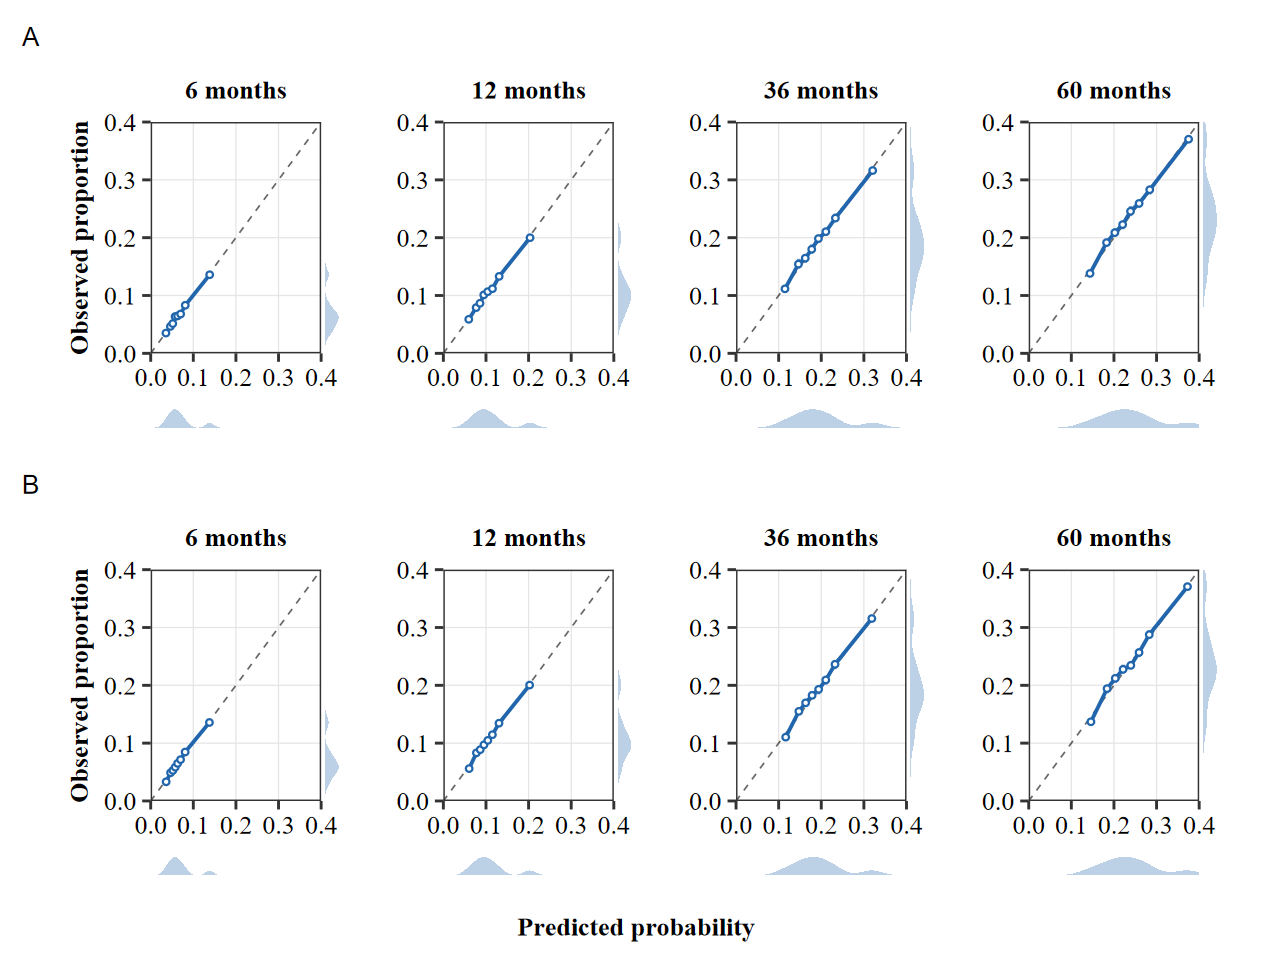

In [12]:
#| label: calibration-plots-readmission

library(ggplot2); library(patchwork)
tnr <- "Times New Roman"

create_cal_published <- function(data, time_title,
                                 color = "#2166AC",
                                 x_lim = c(0, 0.4), x_by = 0.1,
                                 y_lim = x_lim,     y_by = x_by,
                                 show_x_label = FALSE, show_y_label = FALSE) {
  fixed_margin <- ggplot2::margin(5, 2, 5, 5)

  .label_fmt <- function(lim)
    scales::number_format(accuracy = ifelse(diff(lim) <= 0.02, 0.001,
                                     ifelse(diff(lim) <= 0.2,  0.01, 0.1)))

  main <- ggplot2::ggplot(data, ggplot2::aes(x = mean_predicted, y = observed)) +
    ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed",
                         color = "black", linewidth = 0.4, alpha = 0.6) +
    ggplot2::geom_ribbon(ggplot2::aes(ymin = observed_lower, ymax = observed_upper),
                         alpha = 0.3, fill = color) +
    ggplot2::geom_line(color = color, linewidth = 0.9) +
    ggplot2::geom_errorbar(ggplot2::aes(ymin = observed_lower, ymax = observed_upper),
                           width = 0.02 * diff(x_lim), color = color,
                           alpha = 0.6, linewidth = 0.5) +
    ggplot2::geom_point(size = 1, color = color, fill = "white",
                        shape = 21, stroke = 0.8) +
    ggplot2::scale_x_continuous(limits = x_lim, expand = c(0, 0),
                                 breaks = seq(x_lim[1], x_lim[2], by = x_by),
                                 labels = .label_fmt(x_lim)) +
    ggplot2::scale_y_continuous(limits = y_lim, expand = c(0, 0),
                                 breaks = seq(y_lim[1], y_lim[2], by = y_by),
                                 labels = .label_fmt(y_lim)) +
    ggplot2::labs(x = "Predicted probability", y = "Observed proportion",
                  subtitle = time_title) +
    ggplot2::theme_bw(base_size = 15, base_family = tnr) +
    ggplot2::theme(
      plot.subtitle    = ggplot2::element_text(size = 13, face = "bold", hjust = 0.5),
      panel.grid.major = ggplot2::element_line(color = "grey90", linewidth = 0.3),
      panel.grid.minor = ggplot2::element_blank(),
      axis.ticks.length = ggplot2::unit(1.5, "mm"),
      axis.text        = ggplot2::element_text(size = 13, color = "black"),
      axis.title       = ggplot2::element_text(size = 13, face = "bold"),
      axis.title.x     = ggplot2::element_text(
        color = if (show_x_label) "black" else NA, size = 13, face = "bold"),
      axis.title.y     = ggplot2::element_text(
        color = if (show_y_label) "black" else NA, size = 13, face = "bold"),
      plot.margin      = fixed_margin
    )

  right_dens <- ggplot2::ggplot(data, ggplot2::aes(x = observed)) +
    ggplot2::geom_density(fill = color, alpha = 0.3, color = NA) +
    ggplot2::scale_x_continuous(limits = y_lim, expand = c(0, 0)) +
    ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, 0.25))) +
    ggplot2::coord_flip() +
    ggplot2::theme_void() +
    ggplot2::theme(plot.margin = ggplot2::margin(5, 5, 5, 0))

  bottom_dens <- ggplot2::ggplot(data, ggplot2::aes(x = mean_predicted)) +
    ggplot2::geom_density(fill = color, alpha = 0.3, color = NA) +
    ggplot2::scale_x_continuous(limits = x_lim, expand = c(0, 0)) +
    ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, 0.25))) +
    ggplot2::theme_void() +
    ggplot2::theme(plot.margin = ggplot2::margin(0, 2, 0, 5))

  design <- c(
    patchwork::area(t = 1, l = 1, b = 10, r = 10),
    patchwork::area(t = 1, l = 11, b = 10, r = 11),
    patchwork::area(t = 11, l = 1, b = 11, r = 10)
  )
  main + right_dens + bottom_dens + patchwork::plot_layout(design = design)
}

.make_cal_panel <- function(cal_obj, color, x_lim, x_by,
                            y_lim = x_lim, y_by = x_by) {
  curves <- cal_obj$calibration_curves
  if ("observed_min" %in% names(curves) && !"observed_lower" %in% names(curves)) {
    curves$observed_lower <- curves$observed_min
    curves$observed_upper <- curves$observed_max
  }
  curves <- dplyr::mutate(curves, time_label = paste0(time_months, " months"))
  time_levels <- paste0(sort(unique(curves$time_months)), " months")
  n_plots <- length(time_levels); n_cols <- 4L; n_rows <- ceiling(n_plots / n_cols)

  plots <- lapply(seq_along(time_levels), function(i) {
    col_idx <- (i - 1L) %% n_cols
    row_idx <- (i - 1L) %/% n_cols
    show_y  <- col_idx == 0L
    is_last <- row_idx == (n_rows - 1L)
    n_last  <- n_plots - (n_rows - 1L) * n_cols
    show_x  <- is_last && col_idx == floor((n_last - 1L) / 2L)
    create_cal_published(
      dplyr::filter(curves, time_label == time_levels[i]),
      time_levels[i], color = color,
      x_lim = x_lim, x_by = x_by,
      y_lim = y_lim, y_by = y_by,
      show_x_label = show_x, show_y_label = show_y
    )
  })
  patchwork::wrap_plots(plots, ncol = n_cols) +
    patchwork::plot_annotation(theme = ggplot2::theme(plot.margin = ggplot2::margin(10, 10, 10, 10)))
}

# ── Readmission panels (blue) ─────────────────────────────────────────────────
combined_readmit_full <- .make_cal_panel(cal_results$full_ph,
  color = "#2166AC", x_lim = c(0, 0.4), x_by = 0.1)
combined_readmit_shap <- .make_cal_panel(cal_results$shap_clean,
  color = "#2166AC", x_lim = c(0, 0.4), x_by = 0.1)

final_readmit <- patchwork::wrap_plots(
  patchwork::wrap_elements(combined_readmit_full & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  patchwork::wrap_elements(combined_readmit_shap & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  ncol = 1
) +
  patchwork::plot_annotation(
    tag_levels = "A",
    caption = "Predicted probability",
    theme = ggplot2::theme(
      plot.caption = ggplot2::element_text(size = 13, face = "bold", hjust = 0.5, vjust = 1, family = tnr),
      plot.tag     = ggplot2::element_text(face = "bold", size = 18, family = tnr),
      plot.tag.position = c(0.00, 0.97)
    )
  )
print(final_readmit)

ggplot2::ggsave(file.path(project_root, "cons/_figs/readmission_calibration_combined_AB.tiff"),
  final_readmit, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm",
  dpi = 600, compression = "lzw")
ggplot2::ggsave(file.path(project_root, "cons/_figs/readmission_calibration_combined_AB.png"),
  final_readmit, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm", dpi = 600)


In [13]:
#| label: calibration-plots-death

# ── Mortality panels (red) ────────────────────────────────────────────────────
combined_death_full <- .make_cal_panel(death_cal_full$full_ph,
  color = "#B2182B", y_lim = c(0, 0.05), y_by = 0.01, x_lim = c(0, 0.05), x_by = 0.02)
combined_death_shap <- .make_cal_panel(death_cal_full$shap_clean,
  color = "#B2182B", y_lim = c(0, 0.05), y_by = 0.01, x_lim = c(0, 0.05), x_by = 0.02)

final_death <- patchwork::wrap_plots(
  patchwork::wrap_elements(combined_death_full & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  patchwork::wrap_elements(combined_death_shap & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  ncol = 1
) +
  patchwork::plot_annotation(
    tag_levels = "A",
    caption = "Predicted probability",
    theme = ggplot2::theme(
      plot.caption      = ggplot2::element_text(size = 13, face = "bold", hjust = 0.5, vjust = 1, family = tnr),
      plot.tag          = ggplot2::element_text(face = "bold", size = 18, family = tnr),
      plot.tag.position = c(0.00, 0.97)
    )
  )
print(final_death)

ggplot2::ggsave(file.path(project_root, "cons/_figs/mortality_calibration_combined_AB.tiff"),
  final_death, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm",
  dpi = 600, compression = "lzw")
ggplot2::ggsave(file.path(project_root, "cons/_figs/mortality_calibration_combined_AB.png"),
  final_death, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm", dpi = 600)

: [1m[33mError[39m in `UseMethod()`:[22m
[33m![39m no applicable method for 'mutate' applied to an object of class "NULL"


## 3. Dual metrics for pending models

Models that do not yet have dual metrics in `amalisis.xlsx`:
- `formula_readmit` + `formula_death` (Full PH base)
- `formula_readmit_updated` + `formula_death_updated` (Full PH updated)
- `formula_shap_death_interact` (paired with SHAP readmit clean)
- `formula_shap_death` as implementation model (paired with SHAP readmit clean)

We use `k_folds = 5` with `eval_times = c(6, 12, 36, 60, 108)`.

In [ ]:
#| label: dual-pending
#| message: false

gc()
# --- Dual metrics for pending models ---
EVAL_TIMES <- c(6, 12, 36, 60, 108)
K_FOLDS <- 5

pending_configs <- list(
  full_ph_base = list(
    label = "Full PH base",
    readmit = if (exists("formula_readmit")) formula_readmit else NULL,
    death = if (exists("formula_death")) formula_death else NULL
  ),
  full_ph_upd = list(
    label = "Full PH updated",
    readmit = if (exists("formula_readmit_updated")) formula_readmit_updated else NULL,
    death = if (exists("formula_death_updated")) formula_death_updated else NULL
  ),
  shap_readmit_clean_death_interact = list(
    label = "SHAP clean readmit + SHAP death interact",
    readmit = if (exists("formula_shap_readmit_clean_updated")) formula_shap_readmit_clean_updated else NULL,
    death = if (exists("formula_shap_death_interact")) formula_shap_death_interact else NULL
  ),
  shap_readmit_interact_death_interact = list(
    label = "SHAP interact readmit + SHAP death interact",
    readmit = if (exists("formula_shap_readmit_interact")) formula_shap_readmit_interact else NULL,
    death = if (exists("formula_shap_death_interact")) formula_shap_death_interact else NULL
  ),
  shap_death_implem = list(
    label = "SHAP clean readmit + SHAP death (13 vars)",
    readmit = if (exists("formula_shap_readmit_clean_updated")) formula_shap_readmit_clean_updated else NULL,
    death = if (exists("formula_shap_death")) formula_shap_death else NULL
  )
)

# Filter configurations with available formulas
pending_configs <- pending_configs[
  sapply(pending_configs, function(x) !is.null(x$readmit) && !is.null(x$death))
]

cat("Pending configurations to evaluate:\n")
for (nm in names(pending_configs)) {
  cat(sprintf("  - %s: %s\n", nm, pending_configs[[nm]]$label))
}

Pending configurations to evaluate:
  - full_ph_base: Full PH base
  - full_ph_upd: Full PH updated
  - shap_readmit_clean_death_interact: SHAP clean readmit + SHAP death interact
  - shap_readmit_interact_death_interact: SHAP interact readmit + SHAP death interact
  - shap_death_implem: SHAP clean readmit + SHAP death (13 vars)


In [ ]:
#| label: run-dual-pending
#| message: false
#| cache: false

dual_pending_results <- list()

for (nm in names(pending_configs)) {
  cfg <- pending_configs[[nm]]
  cat(sprintf("\n=== Dual: %s ===\n", cfg$label))
  flush.console()
  
  dual_pending_results[[nm]] <- evaluate_dual_cox_python_style(
    formula_readmit = cfg$readmit,
    formula_death = cfg$death,
    imputed_list = py_corrected_datasets_boot,
    k_folds = K_FOLDS,
    eval_times = EVAL_TIMES
  )
  
  cat(sprintf("  OK - %s\n", cfg$label))
  print(dual_pending_results[[nm]]$summary[dual_pending_results[[nm]]$summary$Time == "Global", ])
  flush.console()
}


=== Dual: Full PH base ===
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  OK - Full PH base
          Risk        Metric   Time       mean          sd       q025       q975  n
6        Death           IBS Global 0.09064768 0.004229170 0.08372872 0.09815445 25
12       Death Uno's C-Index Global 0.74214997 0.010699318 0.72321439 0.76008314 25
18 Readmission           IBS Global 0.35997618 0.008063858 0.34289480 0.37079366 25
24 Readmission Uno's C-Index Global 0.60400589 0.005524259 0.59474480 0.61462141 25

=== Dual: Full PH updated ===
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  OK - Full PH updated
          Risk        Metric   Time       mean          sd       q025       q975  n
6        Death           IBS Global 0.09063461 0.004235421 0.08371259 0.09813881 25
12       Death Uno's

~ 9 min


## 4. DeepSurv models (sensitivity analysis)

The `formula_shap_ds_*` models are defined in `prediction24_converted.ipynb`.
If the `.Rdata` file `pred24_ndp_2026_05_02.Rdata` is available, we load it to obtain the DS formulas.

In [ ]:
#| label: ds-setup
#| message: false

ds_rdata <- list.files(
  file.path(project_root, "data", "20241015_out"),
  pattern = "pred24_ndp_.*\\.Rdata$",
  full.names = TRUE
)

ds_formulas_available <- FALSE

if (length(ds_rdata) > 0) {
  # Load only DS formulas (without overwriting py_corrected_datasets)
  env_ds <- new.env()
  load(ds_rdata[length(ds_rdata)], envir = env_ds)
  
  ds_formula_names <- ls(env_ds, pattern = "formula_shap_ds_")
  cat("DS formulas found:\n")
  for (fn in ds_formula_names) {
    cat(sprintf("  - %s\n", fn))
    assign(fn, get(fn, envir = env_ds), envir = .GlobalEnv)
  }
  
  if (length(ds_formula_names) > 0) {
    ds_formulas_available <- TRUE
  }
} else {
  cat("No prediction24 .Rdata file found.\n")
  cat("If necessary, define DS formulas manually from prediction24_converted.ipynb.\n")
}

DS formulas found:
  - formula_shap_ds_death
  - formula_shap_ds_death_interact
  - formula_shap_ds_death_updated
  - formula_shap_ds_readmit
  - formula_shap_ds_readmit_clean
  - formula_shap_ds_readmit_clean_updated
  - formula_shap_ds_readmit_interact


In [ ]:
#| label: ds-dual
#| message: false
#| cache: false

if (ds_formulas_available && exists("formula_shap_ds_readmit_clean_updated")) {
  
  ds_configs <- list(
    ds_readmit_clean_ds_death = list(
      label = "DS readmit clean + DS death",
      readmit = formula_shap_ds_readmit_clean_updated,
      death = if (exists("formula_shap_ds_death_updated")) formula_shap_ds_death_updated else NULL
    ),
    ds_readmit_interact_ds_death = list(
      label = "DS readmit interact + DS death",
      readmit = if (exists("formula_shap_ds_readmit_interact")) formula_shap_ds_readmit_interact else NULL,
      death = if (exists("formula_shap_ds_death_updated")) formula_shap_ds_death_updated else NULL
    ),
    ds_readmit_interact_ds_death_interact = list(
      label = "DS readmit interact + DS death interact",
      readmit = if (exists("formula_shap_ds_readmit_interact")) formula_shap_ds_readmit_interact else NULL,
      death = if (exists("formula_shap_ds_death_interact")) formula_shap_ds_death_interact else NULL
    ),
    ds_readmit_clean_full_death = list(
      label = "DS readmit clean + Full PH death",
      readmit = formula_shap_ds_readmit_clean_updated,
      death = formula_death_updated2
    )
  )
  
  # Filter out NULL entries
  ds_configs <- ds_configs[
    sapply(ds_configs, function(x) !is.null(x$readmit) && !is.null(x$death))
  ]
  
  ds_dual_results <- list()
  
  for (nm in names(ds_configs)) {
    cfg <- ds_configs[[nm]]
    cat(sprintf("\n=== Dual DS: %s ===\n", cfg$label))
    flush.console()
    
    ds_dual_results[[nm]] <- evaluate_dual_cox_python_style(
      formula_readmit = cfg$readmit,
      formula_death = cfg$death,
      imputed_list = py_corrected_datasets,
      k_folds = K_FOLDS,
      eval_times = EVAL_TIMES
    )
    
    cat(sprintf("  OK - %s\n", cfg$label))
    print(ds_dual_results[[nm]]$summary[ds_dual_results[[nm]]$summary$Time == "Global", ])
    flush.console()
  }
  
} else {
  cat("DS formulas not available. Skipping this section.\n")
}


=== Dual DS: DS readmit clean + DS death ===
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  OK - DS readmit clean + DS death
          Risk        Metric   Time       mean          sd       q025       q975  n
6        Death           IBS Global 0.09074216 0.004242869 0.08361252 0.09825256 25
12       Death Uno's C-Index Global 0.74333504 0.011914031 0.72453398 0.76179805 25
18 Readmission           IBS Global 0.35989532 0.008078766 0.34292641 0.37083554 25
24 Readmission Uno's C-Index Global 0.60516831 0.005476651 0.59626414 0.61597993 25

=== Dual DS: DS readmit interact + DS death ===
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  OK - DS readmit interact + DS death
          Risk        Metric   Time       mean          sd       q025       q975  n
6        Death           IBS Global 0.

Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 


~ 10 minutes

### 4b. Calibration analysis

In [ ]:
#| label: ici-readmit-ds
readmit_models_ds <- list(
  ds_readmit_clean_ds_death = list(
    label          = "DS readmit clean + DS death",
    formula_readmit = formula_shap_ds_readmit_clean_updated,
    formula_death   = formula_shap_ds_death_updated
  ),
  ds_readmit_interact_ds_death = list(
    label          = "DS readmit interact + DS death",
    formula_readmit = formula_shap_ds_readmit_interact,
    formula_death   = formula_shap_ds_death_updated
  ),
  ds_readmit_interact_ds_death_interact = list(
    label          = "DS readmit interact + DS death interact",
    formula_readmit = formula_shap_ds_readmit_interact,
    formula_death   = formula_shap_ds_death_interact
  ),
  ds_readmit_clean_full_death = list(
    label          = "DS readmit clean + Full PH death",
    formula_readmit = formula_shap_ds_readmit_clean_updated,
    formula_death   = formula_death_updated2
  )
)

cal_results_ds <- list()

for (nm in names(readmit_models_ds)) {
  cfg <- readmit_models_ds[[nm]]
  if (is.null(cfg$formula_readmit) || is.null(cfg$formula_death)) {
    cat(sprintf("  SKIP %s (formula not available)\n", nm)); next
  }
  cat(sprintf("\n=== DS readmit: %s ===\n", cfg$label)); flush.console()
  cal_results_ds[[nm]] <- calibrate_cscox_aj_grouped_corr(
    formula_readmit  = cfg$formula_readmit,
    formula_death    = cfg$formula_death,
    data             = py_corrected_datasets_boot,
    times            = CAL_TIMES,
    validation       = "cv",
    folds            = 5L,
    n_repeats        = CAL_N_REPEATS,
    compute_ici      = TRUE,
    ici_times        = CAL_ICI_TIMES,
    make_plots       = FALSE,
    parallel_cv      = TRUE,
    future_scheduling = 2,
    verbose          = TRUE,
    debug_fit        = FALSE,
    seed             = 2125
  )
  print(cal_results_ds[[nm]]$pooled_summary[, c("time_months","ici_mean","ici_sd","ece_mean","eo_mean")])
  flush.console()
}



=== DS readmit: DS readmit clean + DS death ===
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 6, 12, 36, 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done
  time_months    ici_mean       ici_sd    ece_mean   eo_mean
1           6 0.006575880 0.0001703335 0.001963842 0.9897999
2          12 0.008112481 0.0001535149 0.002679055 0.9899841
3          36 0.009903925 0.0002871058 0.003533929 0.9880772
4          60 0.010496369 0.0003649191 0.004586299 0.9846983

=== DS readmit: DS readmit interact + DS death ===
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 6, 12, 36, 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done
  time_months    ici_mea

There were 40 warnings (use warnings() to see them)


~ 38 minutes

In [ ]:
#| label: ici-death-ds
death_models_ds <- list(
  shap_ds_death_updated = list(
    label   = "DS death (updated)",
    formula = formula_shap_ds_death_updated
  ),
  shap_ds_death_interact = list(
    label   = "DS death + interactions",
    formula = formula_shap_ds_death_interact
  )
)

death_cal_results_ds <- list()
death_cal_full_ds    <- list()

for (nm in names(death_models_ds)) {
  cfg <- death_models_ds[[nm]]
  if (is.null(cfg$formula)) {
    cat(sprintf("  SKIP %s (formula not available)\n", nm)); next
  }
  cat(sprintf("\n=== DS death: %s ===\n", cfg$label)); flush.console()
  result <- calibrate_death_km_grouped(
    formula     = cfg$formula,
    data        = py_corrected_datasets_boot,
    times       = c(6, 12, 36, 60),
    time_col    = "death_time_from_disch_m",
    event_col   = "death_event",
    validation  = "cv",
    folds       = 5L,
    n_repeats   = CAL_N_REPEATS,
    parallel_cv = TRUE,
    verbose     = TRUE,
    seed        = 2125
  )
  death_cal_results_ds[[nm]] <- result$flat
  death_cal_full_ds[[nm]]    <- result
  print(result$pooled_summary[, c("time_months","ici_mean","ici_sd","ece_mean","eo_mean")])
  flush.console()
}



=== DS death: DS death (updated) ===

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x4
  Pooling repetition 20/20

  Pooled calibration summary:
  time_months    ici_mean       ici_sd     ece_mean  eo_mean
1           6 0.002247822 4.261428e-05 0.0006026473 1.005386
2          12 0.002887876 4.807262e-05 0.0010344687 1.007631
3          36 0.006316262 9.947851e-05 0.0023011604 1.011124
4          60 0.008633344 1.114809e-04 0.0024752596 1.021330
  time_months    ici_mean       ici_sd     ece_mean  eo_mean
1           6 0.002247822 4.261428e-05 0.0006026473 1.005386
2          12 0.002887876 4.807262e-05 0.0010344687 1.007631
3          36 0.006316262 9.947851e-05 0.0023011604 1.011124
4          60 0.008633344 1.114809e-04 0.0024752596 1.021330

=== DS death: DS death + interactions ===

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (1

There were 35 warnings (use warnings() to see them)



## 5. Consolidated model table

Builds a table with all candidate models and their main dual metrics.

In [ ]:
#| label: extract-metrics
#| message: false

# --- Helper to extract metrics from an evaluate_dual_cox_python_style object ---
extract_dual_metrics <- function(obj, model_id, family) {
  if (is.null(obj) || !is.list(obj) || is.null(obj$summary)) {
    return(NULL)
  }
  
  s <- obj$summary
  
  # Global
  row_global <- s[s$Time == "Global", ]
  
  # Dual UnoC = (UnoC_readmit + UnoC_death) / 2
  unoc_r <- row_global$mean[row_global$Metric == "Uno's C-Index" & row_global$Risk == "Readmission"]
  unoc_d <- row_global$mean[row_global$Metric == "Uno's C-Index" & row_global$Risk == "Death"]
  dual_unoC <- if (length(unoc_r) == 1 && length(unoc_d) == 1) (unoc_r + unoc_d) / 2 else NA
  
  # Dual IBS = (IBS_readmit + IBS_death) / 2
  ibs_r <- row_global$mean[row_global$Metric == "IBS" & row_global$Risk == "Readmission"]
  ibs_d <- row_global$mean[row_global$Metric == "IBS" & row_global$Risk == "Death"]
  dual_ibs <- if (length(ibs_r) == 1 && length(ibs_d) == 1) (ibs_r + ibs_d) / 2 else NA
  
  # By horizon (d_C_T, d_IBS_T)
  d_C_T <- list()
  d_IBS_T <- list()
  for (t in c("6", "12", "36", "60")) {
    s_t <- s[s$Time == t, ]
    if (nrow(s_t) > 0) {
      c_r <- s_t$mean[s_t$Metric == "Uno's C-Index" & s_t$Risk == "Readmission"]
      c_d <- s_t$mean[s_t$Metric == "Uno's C-Index" & s_t$Risk == "Death"]
      d_C_T[[t]] <- if (length(c_r) == 1 && length(c_d) == 1) (c_r + c_d) / 2 else NA
      
      ibs_r <- s_t$mean[s_t$Metric == "IBS" & s_t$Risk == "Readmission"]
      ibs_d <- s_t$mean[s_t$Metric == "IBS" & s_t$Risk == "Death"]
      d_IBS_T[[t]] <- if (length(ibs_r) == 1 && length(ibs_d) == 1) (ibs_r + ibs_d) / 2 else NA
    }
  }
  
  # Pooled individual
  unoc_readmit <- if (length(unoc_r) == 1) unoc_r else NA
  unoc_death <- if (length(unoc_d) == 1) unoc_d else NA
  ibs_readmit <- if (length(ibs_r) == 1) ibs_r else NA
  ibs_death <- if (length(ibs_d) == 1) ibs_d else NA
  
  data.frame(
    model_id = model_id,
    family = family,
    dual_UnoC = round(dual_unoC, 4),
    dual_IBS = round(dual_ibs, 4),
    d_C_6 = round(d_C_T[["6"]], 4),
    d_C_12 = round(d_C_T[["12"]], 4),
    d_C_36 = round(d_C_T[["36"]], 4),
    d_C_60 = round(d_C_T[["60"]], 4),
    d_IBS_6 = round(d_IBS_T[["6"]], 4),
    d_IBS_12 = round(d_IBS_T[["12"]], 4),
    d_IBS_36 = round(d_IBS_T[["36"]], 4),
    d_IBS_60 = round(d_IBS_T[["60"]], 4),
    UnoC_readmit = round(unoc_readmit, 4),
    UnoC_death = round(unoc_death, 4),
    IBS_readmit = round(ibs_readmit, 4),
    IBS_death = round(ibs_death, 4),
    stringsAsFactors = FALSE
  )
}

cat("Helper function extract_dual_metrics defined.\n")

Helper function extract_dual_metrics defined.


In [ ]:
#| label: build-table
#| message: false

# --- List of all available result objects ---
# Objects from prediction22 (should be in the environment)
result_objects <- list(
  # Full PH family
  full_ph_base = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$full_ph_base else NULL,
    id = "formula_readmit + formula_death",
    fam = "Full PH"
  ),
  full_ph_upd = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$full_ph_upd else NULL,
    id = "formula_readmit_updated + formula_death_updated",
    fam = "Full PH"
  ),
  full_ph_upd2 = list(
    obj = if (exists("results_upd2_py")) results_upd2_py else NULL,
    id = "formula_readmit_updated2 + formula_death_updated2",
    fam = "Full PH"
  ),
  
  # xgb2 family (SHAP)
  shap_clean = list(
    obj = if (exists("results_shap_xgb_py_upd_best_perf")) results_shap_xgb_py_upd_best_perf else NULL,
    id = "formula_shap_readmit_clean_updated + formula_death_updated2",
    fam = "xgb2"
  ),
  shap_death_implem = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$shap_death_implem else NULL,
    id = "formula_shap_readmit_clean_updated + formula_shap_death",
    fam = "xgb2"
  ),
  shap_readmit_interact = list(
    obj = if (exists("results_shap_xgb_py_upd_best_perf3")) results_shap_xgb_py_upd_best_perf3 else NULL,
    id = "formula_shap_readmit_interact + formula_death_updated2",
    fam = "xgb2"
  ),
  shap_readmit_clean_death_interact = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$shap_readmit_clean_death_interact else NULL,
    id = "formula_shap_readmit_clean_updated + formula_shap_death_interact",
    fam = "xgb2"
  ),
  shap_readmit_interact_death_interact = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$shap_readmit_interact_death_interact else NULL,
    id = "formula_shap_readmit_interact + formula_shap_death_interact",
    fam = "xgb2"
  )#,
  
  # # DS family
  # ds_clean = list(
  #   obj = if (exists("ds_dual_results")) ds_dual_results$ds_readmit_clean_ds_death else NULL,
  #   id = "formula_shap_ds_readmit_clean_updated + formula_shap_ds_death_updated",
  #   fam = "ds"
  # ),
  # ds_interact = list(
  #   obj = if (exists("ds_dual_results")) ds_dual_results$ds_readmit_interact_ds_death else NULL,
  #   id = "formula_shap_ds_readmit_interact + formula_shap_ds_death_updated",
  #   fam = "ds"
  # ),
  # ds_readmit_clean_full_death = list(
  #   obj = if (exists("ds_dual_results")) ds_dual_results$ds_readmit_clean_full_death else NULL,
  #   id = "formula_shap_ds_readmit_clean_updated + formula_death_updated2",
  #   fam = "ds"
  # )
)

# --- Extract metrics ---
table_rows <- lapply(names(result_objects), function(nm) {
  entry <- result_objects[[nm]]
  if (is.null(entry$obj)) return(NULL)
  extract_dual_metrics(entry$obj, entry$id, entry$fam)
})
table_rows <- table_rows[!sapply(table_rows, is.null)]

if (length(table_rows) > 0) {
  consolidated_table <- do.call(rbind, table_rows)
  rownames(consolidated_table) <- NULL
  
  cat("=== CONSOLIDATED TABLE OF DUAL METRICS ===\n\n")
  knitr::kable(consolidated_table, row.names = FALSE, format = "markdown")

  # Save
  write.csv(consolidated_table,
            file.path(project_root, "cons", "_out", "tabla_consolidada_dual.csv"),
            row.names = FALSE)
  cat("\nSaved to: cons/_out/tabla_consolidada_dual.csv\n")
} else {
  cat("No rows to consolidate. Run the previous sections first.\n")
}

=== CONSOLIDATED TABLE OF DUAL METRICS ===


Saved to: cons/_out/tabla_consolidada_dual.csv



## 6. ICI consolidated by horizon

Extract ICI at 6, 12, 36, 60 months and build a table + plot.

=== ICI / ECE / E-O for READMISSION models ===

                model     outcome time    ICI ICI_sd    ECE    E_O
 SHAP clean (primary) Readmission    6 0.0067  2e-04 0.0022 0.9910
 SHAP clean (primary) Readmission   12 0.0077  1e-04 0.0032 0.9912
 SHAP clean (primary) Readmission   36 0.0090  1e-04 0.0050 0.9893
 SHAP clean (primary) Readmission   60 0.0094  1e-04 0.0061 0.9860
              Full PH Readmission    6 0.0065  1e-04 0.0022 0.9898
              Full PH Readmission   12 0.0080  1e-04 0.0027 0.9900
              Full PH Readmission   36 0.0096  3e-04 0.0039 0.9881
              Full PH Readmission   60 0.0103  3e-04 0.0051 0.9848
  SHAP + interactions Readmission    6 0.0067  1e-04 0.0025 0.9923
  SHAP + interactions Readmission   12 0.0079  1e-04 0.0035 0.9926
  SHAP + interactions Readmission   36 0.0099  3e-04 0.0046 0.9910
  SHAP + interactions Readmission   60 0.0106  2e-04 0.0062 0.9877


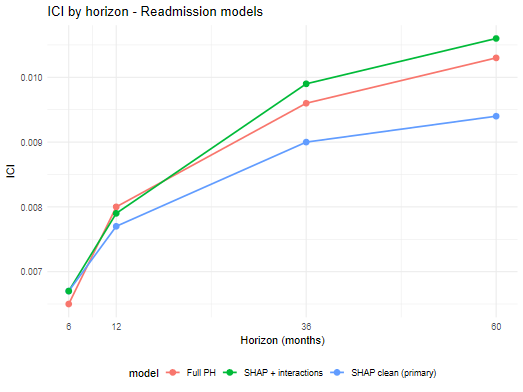

In [ ]:
#| label: ici-table
#| message: false

# --- ICI for readmission ---
ici_readmit_rows <- list()

if (exists("cal_results")) {
  for (nm in names(cal_results)) {
    label <- readmit_models_for_cal[[nm]]$label
    ps <- cal_results[[nm]]$pooled_summary
    for (i in seq_len(nrow(ps))) {
      if (ps$time_months[i] %in% c(6, 12, 36, 60)) {
        ici_readmit_rows[[length(ici_readmit_rows) + 1]] <- data.frame(
          model = label,
          outcome = "Readmission",
          time = ps$time_months[i],
          ICI = round(ps$ici_mean[i], 4),
          ICI_sd = round(ps$ici_sd[i], 4),
          ECE = round(ps$ece_mean[i], 4),
          E_O = round(ps$eo_mean[i], 4),
          stringsAsFactors = FALSE
        )
      }
    }
  }
}

if (length(ici_readmit_rows) > 0) {
  ici_readmit_table <- do.call(rbind, ici_readmit_rows)
  cat("=== ICI / ECE / E-O for READMISSION models ===\n\n")
  print(ici_readmit_table, row.names = FALSE)
  
  write.csv(ici_readmit_table,
            file.path(project_root, "cons", "_out", "ici_readmit_multihorizonte.csv"),
            row.names = FALSE)
  
  # Plot
  if (requireNamespace("ggplot2", quietly = TRUE)) {
    p <- ggplot2::ggplot(ici_readmit_table,
                         ggplot2::aes(x = time, y = ICI, color = model, group = model)) +
      ggplot2::geom_line(linewidth = 0.8) +
      ggplot2::geom_point(size = 2.5) +
      ggplot2::scale_x_continuous(breaks = c(6, 12, 36, 60)) +
      ggplot2::labs(title = "ICI by horizon - Readmission models",
                    x = "Horizon (months)", y = "ICI") +
      ggplot2::theme_minimal() +
      ggplot2::theme(legend.position = "bottom")
    print(p)
  }
} else {
  cat("No ICI data available. Run section 2 first.\n")
}

=== ICI / ECE / E-O for MORTALITY models ===

               model   outcome time    ICI    ECE    E_O
   Full PH (primary) Mortality    6 0.0024 0.0007 1.0069
   Full PH (primary) Mortality   12 0.0031 0.0010 1.0096
   Full PH (primary) Mortality   36 0.0067 0.0023 1.0142
   Full PH (primary) Mortality   60 0.0091 0.0025 1.0246
      SHAP (13 vars) Mortality    6 0.0015 0.0007 1.0067
      SHAP (13 vars) Mortality   12 0.0023 0.0010 1.0087
      SHAP (13 vars) Mortality   36 0.0056 0.0022 1.0153
      SHAP (13 vars) Mortality   60 0.0082 0.0030 1.0283
 SHAP + interactions Mortality    6 0.0025 0.0007 1.0072
 SHAP + interactions Mortality   12 0.0032 0.0012 1.0099
 SHAP + interactions Mortality   36 0.0069 0.0026 1.0145
 SHAP + interactions Mortality   60 0.0090 0.0027 1.0255


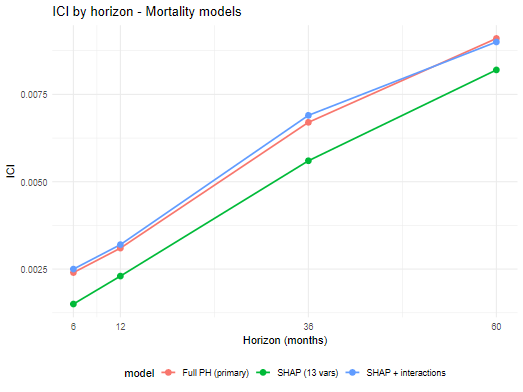

In [ ]:
#| label: ici-death-table
#| message: false

if (exists("death_cal_results") && length(death_cal_results) > 0) {
  ici_death_rows <- list()
  for (nm in names(death_cal_results)) {
    label <- death_models_for_cal[[nm]]$label
    df <- death_cal_results[[nm]]
    for (i in seq_len(nrow(df))) {
      ici_death_rows[[length(ici_death_rows) + 1]] <- data.frame(
        model = label,
        outcome = "Mortality",
        time = df$time_months[i],
        ICI = round(df$ici[i], 4),
        ECE = round(df$ece[i], 4),
        E_O = round(df$eo_ratio[i], 4),
        stringsAsFactors = FALSE
      )
    }
  }
  
  ici_death_table <- do.call(rbind, ici_death_rows)
  cat("=== ICI / ECE / E-O for MORTALITY models ===\n\n")
  print(ici_death_table, row.names = FALSE)
  
  write.csv(ici_death_table,
            file.path(project_root, "cons", "_out", "ici_death_multihorizonte.csv"),
            row.names = FALSE)
  
  if (requireNamespace("ggplot2", quietly = TRUE)) {
    p <- ggplot2::ggplot(ici_death_table,
                         ggplot2::aes(x = time, y = ICI, color = model, group = model)) +
      ggplot2::geom_line(linewidth = 0.8) +
      ggplot2::geom_point(size = 2.5) +
      ggplot2::scale_x_continuous(breaks = c(6, 12, 36, 60)) +
      ggplot2::labs(title = "ICI by horizon - Mortality models",
                    x = "Horizon (months)", y = "ICI") +
      ggplot2::theme_minimal() +
      ggplot2::theme(legend.position = "bottom")
    print(p)
  }
} else {
  cat("No ICI data for death available. Run section 2b first.\n")
}


## 7. DCA (Decision Curve Analysis)

Evaluates the net benefit of using the model for clinical decisions
at different probability thresholds.

But we uniform the grid of integration from 6 to 60 months (2026-05-30).

In [ ]:
#| label: dca-setup
#| message: false

source("cons/_alt_scripts/adca_from_results_boot.R")            # fuerza motor AJ
source("cons/_alt_scripts/dca_from_results_boot_for_metrics.R")
cat("Sourced: dca_from_results_boot_for_metrics\n")


Sourced: dca_from_results_boot_for_metrics


In [ ]:
#| label: dca-setup-best-perf
#| message: false

if (!exists("results_shap_xgb_py_upd_best_perf")) {
  results_shap_xgb_py_upd_best_perf <- evaluate_dual_cox_python_style(
    formula_readmit = formula_shap_readmit_clean_updated,
    formula_death   = formula_death_updated2,
    imputed_list    = py_corrected_datasets_boot,
    k_folds         = 5,
    eval_times      = c(6, 12, 36, 60)
  )
}

In [ ]:
#| label: dca-setup-best-perf2
#| message: false

results_shap_xgb_py_upd_best_perf2 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_clean_updated,
  formula_death   = formula_shap_death,
  imputed_list    = py_corrected_datasets_boot,
  k_folds = 5, eval_times = c(6, 12, 36, 60)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [ ]:
#| label: full-criteria-upd2-run-ev-mi-cv-python-style-from-step22

results_upd2_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated2,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(6, 12, 36, 60)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [ ]:
#| label: dca-run
#| message: false
#| cache: false

DCA_HORIZONS <- c(6, 12, 36, 60)

dca_model_list <- list(
  full_ph     = results_upd2_py,
  shap_clean  = results_shap_xgb_py_upd_best_perf,
  implemented = results_shap_xgb_py_upd_best_perf2
)

# Compute the full DCA ONCE per model (covers BOTH risks + full summary in a
# single pass). This is the ONLY expensive step; everything else is derived.
dca_models_full <- run_dca_full_summary(dca_model_list, horizons = DCA_HORIZONS)

# Derive the compact per-horizon format (what plot_dca_multi_horizon expects)
# from the already-computed summaries — NO recomputation. Identical to what
# compute_dca_from_boot() would return (same run_adca config, same thresholds).
.dca_compact_from_full <- function(models_full, risk, horizons,
                                   thresholds = seq(0.01, 0.50, by = 0.01)) {
  out <- stats::setNames(vector("list", length(horizons)), as.character(horizons))
  for (h in horizons) {
    per_model <- lapply(models_full, function(m) {
      if (is.null(m)) return(NULL)
      if (!(h %in% as.numeric(m$config$horizons))) return(NULL)
      .dca_extract_horizon(m, risk, h, thresholds)
    })
    out[[as.character(h)]] <- stats::setNames(per_model, names(models_full))
  }
  out
}

dca_readmit <- .dca_compact_from_full(dca_models_full, "readmission", DCA_HORIZONS)
dca_death   <- .dca_compact_from_full(dca_models_full, "death",       DCA_HORIZONS)
cat("DCA computed once per model; readmission + mortality derived (no recompute).\n")


  DCA full summary: full_ph | horizons=6, 12, 36, 60
Readmission observed risk: Aalen-Johansen on 25/25 replicate(s). Death: Kaplan-Meier.
  DCA full summary: shap_clean | horizons=6, 12, 36, 60
Readmission observed risk: Aalen-Johansen on 25/25 replicate(s). Death: Kaplan-Meier.
  DCA full summary: implemented | horizons=6, 12, 36, 60
Readmission observed risk: Aalen-Johansen on 25/25 replicate(s). Death: Kaplan-Meier.
DCA computed once per model; readmission + mortality derived (no recompute).


~26 minutes

In [ ]:
#| label: dca-summary-and-panel
#| message: false

# dca_models_full already exists from the dca-run chunk — do NOT recompute.
stopifnot(exists("dca_models_full"))

# Net-benefit summaries per model
dca_nb_full_ph          <- summarize_dca_nb(dca_models_full$full_ph$summary)
dca_nb_shap_clean       <- summarize_dca_nb(dca_models_full$shap_clean$summary)
dca_nb_shap_implemented <- summarize_dca_nb(dca_models_full$implemented$summary)

cat("=== Full PH — useful threshold ranges ===\n")
print(dca_nb_full_ph$any_useful)
cat("\n=== SHAP clean — focus window summary ===\n")
print(dca_nb_shap_clean$focus_summary)
cat("\n=== Both SHAP — focus window summary ===\n")
print(dca_nb_shap_implemented$focus_summary)


=== Full PH — useful threshold ranges ===
# A tibble: 8 × 8
  risk        horizon any_useful_anywhere useful_threshold_min useful_threshold_max max_model_nb max_treat_all_nb max_treat_none_nb
  <chr>         <dbl> <lgl>                              <dbl>                <dbl>        <dbl>            <dbl>             <dbl>
1 death             6 TRUE                                0.01                 0.16      0.00227        -0.00314                  0
2 death            12 TRUE                                0.01                 0.24      0.00443         0.000712                 0
3 death            36 TRUE                                0.01                 0.5       0.0192          0.0188                   0
4 death            60 TRUE                                0.02                 0.37      0.0355          0.0356                   0
5 readmission       6 TRUE                                0.02                 0.26      0.0632          0.0632                   0
6 readmission   

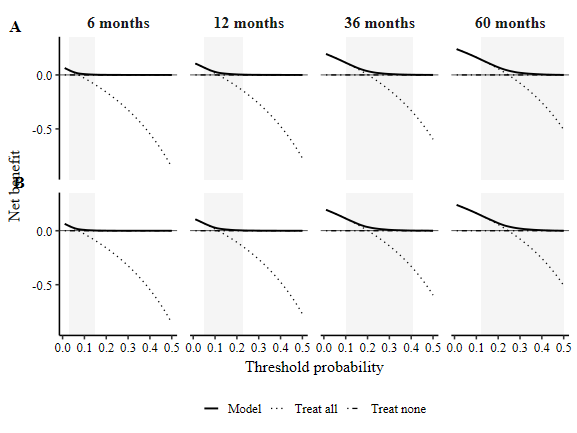

DCA results saved to cons/_out/dca_results.rds


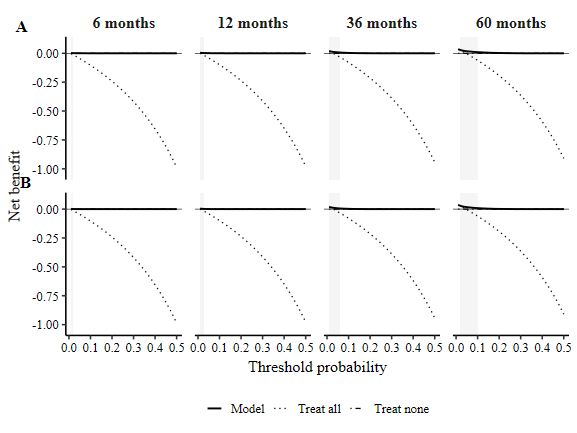

In [ ]:
#| label: dca-panel-figures
#| message: false

p_readmit_panel <- make_dca_panel_figure(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$shap_clean$summary,
  outcome      = "readmission",
  horizons     = c(6, 12, 36, 60)
)
  # ggplot2::labs(
  #   caption = "A: Full PH readmission model; B: SHAP-clean readmission model"
  # )
print(p_readmit_panel)

p_death_panel <- make_dca_panel_figure(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$implemented$summary,
  outcome      = "death",
  horizons     = c(6, 12, 36, 60)
)
  # ggplot2::labs(
  #   caption = "A: Full PH mortality model; B: parsimonious SHAP mortality implementation model"
  # )
print(p_death_panel)

saveRDS(
  list(
    readmit = dca_readmit,
    death   = dca_death,
    models_full = dca_models_full,
    nb_full_ph = dca_nb_full_ph,
    nb_shap_clean = dca_nb_shap_clean,
    nb_implemented = dca_nb_shap_implemented
  ),
  file.path(project_root, "cons", "_out", "dca_results.rds")
)
cat("DCA results saved to cons/_out/dca_results.rds\n")

In [ ]:
#| label: dca-panel-export
#| message: false

fig_dir <- file.path(project_root, "cons", "_figs")
if (!dir.exists(fig_dir)) dir.create(fig_dir, recursive = TRUE)

ggplot2::ggsave(
  file.path(fig_dir, "p_dca_readmit_fullph_vs_shap_clean.png"),
  p_readmit_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm", dpi = 600
)
ggplot2::ggsave(
  file.path(fig_dir, "p_dca_readmit_fullph_vs_shap_clean.pdf"),
  p_readmit_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm",
  device = grDevices::cairo_pdf
)

ggplot2::ggsave(
  file.path(fig_dir, "p_dca_death_fullph_vs_shap_implemented.png"),
  p_death_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm", dpi = 600
)
ggplot2::ggsave(
  file.path(fig_dir, "p_dca_death_fullph_vs_shap_implemented.pdf"),
  p_death_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm",
  device = grDevices::cairo_pdf
)

### NRI & IDI

In [ ]:
#| label: nri-idi-epi-table-models-html
#| message: false
#| results: asis

source(file.path(project_root, "cons/_alt_scripts/nri_idi_from_results_boot.R"))   # AJ competing-aware
source(file.path(project_root, "cons/_hist_scripts/make_nri_idi_epidemiology_table.R"))

NRI_IDI_HORIZONS   <- c(6, 12, 36, 60)
NRI_IDI_CUT_POINTS <- c(0.05, 0.10, 0.20)

# Los 2 mejores modelos: Full PH (referencia) vs SHAP primario (ambos primarios).
# Readmisión = IPCW de riesgo competidor (Aalen-Johansen); muerte = IPCW estándar.
nri_idi_best2 <- run_nri_idi_from_results_boot(
  results_boot_old = results_upd2_py,                    # Full PH updated2
  results_boot_new = results_shap_xgb_py_upd_best_perf,  # SHAP primario
  horizons       = NRI_IDI_HORIZONS,
  cut_points     = NRI_IDI_CUT_POINTS,
  old_label      = "Full PH updated2",
  new_label      = "SHAP primary",
  readmit_method = "aalen-johansen",                     # readmisión competing-aware
  output_dir     = file.path(project_root, "cons", "_out", "nri_idi_best2"),
  prefix         = "nri_idi_best2",
  save_raw       = FALSE
)

# Verificación: AJ aplicado sin fallback (debe ser CR=#réplicas, fallback=0)
cat(sprintf("Readmisión CR=%d | fallback IPCW=%d\n",
            nri_idi_best2$config$n_readmit_competing_risk,
            nri_idi_best2$config$n_readmit_ipcw_fallback))

nri_idi_tab <- make_nri_idi_epidemiology_table(
  reclass_object = nri_idi_best2,
  output_dir = file.path(project_root, "cons", "_out", "nri_idi_epi_best2"),
  prefix     = "nri_idi_epi_best2",
  old_label  = "Full PH updated2",
  new_label  = "SHAP primary"
)

nri_idi_model_table <- cbind(
  Comparison = "Full PH updated2 vs SHAP primary",
  nri_idi_tab$table
)

utils::write.csv(
  nri_idi_model_table,
  file.path(project_root, "cons", "_out", "table_nri_idi_best2.csv"),
  row.names = FALSE
)

Readmission NRI/IDI: competing-risk (Aalen-Johansen) IPCW on 25 replicate(s). Death: standard IPCW.
Readmisión CR=25 | fallback IPCW=0


In [ ]:
#| label: nri-idi-htmltools-table
#| message: false
#| results: asis

library(htmltools)

nri_idi_widget <- htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 550px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: Arial, sans-serif;
      font-size: 12px;
    ",
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(nri_idi_model_table), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(nri_idi_model_table)), function(i) {
          htmltools::tags$tr(
            lapply(nri_idi_model_table[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

htmltools::save_html(
  nri_idi_widget,
  file = file.path(project_root, "cons", "_out", "table_nri_idi_models.html")
)

nri_idi_widget

Full PH updated2 vs SHAP primary,Readmission,6,-0.039 (-0.134 to 0.032),-0.022 (-0.098 to 0.038),-0.017 (-0.051 to 0.014),0.004 (-0.028 to 0.029),0.009 (-0.021 to 0.037),-0.004 (-0.011 to 0.001),-0.000 (-0.001 to 0.001),0.019 (0.016 to 0.022) vs 0.018 (0.016 to 0.022)
Full PH updated2 vs SHAP primary,Readmission,12,-0.048 (-0.138 to 0.007),-0.035 (-0.109 to 0.025),-0.013 (-0.047 to 0.018),-0.012 (-0.042 to 0.011),-0.003 (-0.032 to 0.023),-0.009 (-0.015 to -0.004),-0.000 (-0.002 to 0.000),0.025 (0.022 to 0.029) vs 0.025 (0.022 to 0.028)
Full PH updated2 vs SHAP primary,Readmission,36,-0.042 (-0.103 to -0.006),-0.033 (-0.080 to 0.006),-0.009 (-0.039 to 0.023),-0.008 (-0.025 to 0.009),0.000 (-0.016 to 0.018),-0.008 (-0.014 to -0.002),-0.001 (-0.002 to -0.000),0.034 (0.030 to 0.039) vs 0.033 (0.029 to 0.038)
Full PH updated2 vs SHAP primary,Readmission,60,-0.048 (-0.109 to 0.013),-0.033 (-0.071 to 0.011),-0.014 (-0.049 to 0.024),-0.007 (-0.020 to 0.009),0.005 (-0.007 to 0.024),-0.012 (-0.020 to -0.002),-0.001 (-0.002 to -0.000),0.034 (0.030 to 0.038) vs 0.033 (0.028 to 0.037)
Full PH updated2 vs SHAP primary,Death,6,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.016 (0.008 to 0.023) vs 0.016 (0.008 to 0.023)
Full PH updated2 vs SHAP primary,Death,12,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.022 (0.013 to 0.033) vs 0.022 (0.013 to 0.033)
Full PH updated2 vs SHAP primary,Death,36,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.050 (0.041 to 0.059) vs 0.050 (0.041 to 0.059)
Full PH updated2 vs SHAP primary,Death,60,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.074 (0.066 to 0.084) vs 0.074 (0.066 to 0.084)


### Best model vs. second best model (implemented)

In [ ]:
#| label: nri-idi-epi-table-models-html2
#| message: false
#| results: asis

NRI_IDI_HORIZONS   <- c(6, 12, 36, 60)
NRI_IDI_CUT_POINTS <- c(0.05, 0.10, 0.20)

# Los 2 mejores modelos: Full PH (referencia) vs SHAP primario (ambos primarios).
# Readmisión = IPCW de riesgo competidor (Aalen-Johansen); muerte = IPCW estándar.
nri_idi_best2vs1 <- run_nri_idi_from_results_boot(
  results_boot_old = results_shap_xgb_py_upd_best_perf2, # Full PH updated2
  results_boot_new = results_shap_xgb_py_upd_best_perf,  # SHAP primario
  horizons       = NRI_IDI_HORIZONS,
  cut_points     = NRI_IDI_CUT_POINTS,
  old_label      = "SHAP implemented",
  new_label      = "SHAP primary",
  readmit_method = "aalen-johansen",                     # readmisión competing-aware
  output_dir     = file.path(project_root, "cons", "_out", "nri_idi_best2vs1"),
  prefix         = "nri_idi_best2vs1",
  save_raw       = FALSE
)

# Verificación: AJ aplicado sin fallback (debe ser CR=#réplicas, fallback=0)
cat(sprintf("Readmisión CR=%d | fallback IPCW=%d\n",
            nri_idi_best2vs1$config$n_readmit_competing_risk,
            nri_idi_best2vs1$config$n_readmit_ipcw_fallback))

nri_idi_tab2 <- make_nri_idi_epidemiology_table(
  reclass_object = nri_idi_best2vs1,
  output_dir = file.path(project_root, "cons", "_out", "nri_idi_epi_best2vs1"),
  prefix     = "nri_idi_epi_best2",
  old_label  = "Full PH updated2",
  new_label  = "SHAP primary"
)

nri_idi_model_table2 <- cbind(
  Comparison = "Implemented vs SHAP primary",
  nri_idi_tab2$table
)

utils::write.csv(
  nri_idi_model_table2,
  file.path(project_root, "cons", "_out", "table_nri_idi_best2vs1.csv"),
  row.names = FALSE
)

Readmission NRI/IDI: competing-risk (Aalen-Johansen) IPCW on 25 replicate(s). Death: standard IPCW.
Readmisión CR=25 | fallback IPCW=0


In [ ]:
#| label: nri-idi-htmltools-table2
#| message: false
#| results: asis

library(htmltools)

nri_idi_widget2 <- htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 550px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: Arial, sans-serif;
      font-size: 12px;
    ",
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(nri_idi_model_table2), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(nri_idi_model_table2)), function(i) {
          htmltools::tags$tr(
            lapply(nri_idi_model_table2[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

htmltools::save_html(
  nri_idi_widget2,
  file = file.path(project_root, "cons", "_out", "table_nri_idi_modelsbest2vs1.html")
)

nri_idi_widget2

Implemented vs SHAP primary,Readmission,6,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.018 (0.016 to 0.022) vs 0.018 (0.016 to 0.022)
Implemented vs SHAP primary,Readmission,12,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.025 (0.022 to 0.028) vs 0.025 (0.022 to 0.028)
Implemented vs SHAP primary,Readmission,36,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.033 (0.029 to 0.038) vs 0.033 (0.029 to 0.038)
Implemented vs SHAP primary,Readmission,60,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.033 (0.028 to 0.037) vs 0.033 (0.028 to 0.037)
Implemented vs SHAP primary,Death,6,0.433 (0.125 to 0.689),0.301 (-0.001 to 0.567),0.133 (0.108 to 0.154),0.095 (0.027 to 0.223),0.099 (0.030 to 0.227),-0.004 (-0.006 to -0.002),0.006 (0.003 to 0.010),0.010 (0.005 to 0.014) vs 0.016 (0.008 to 0.023)
Implemented vs SHAP primary,Death,12,0.339 (0.123 to 0.567),0.212 (-0.004 to 0.432),0.128 (0.102 to 0.150),0.087 (0.024 to 0.159),0.095 (0.030 to 0.168),-0.008 (-0.011 to -0.005),0.006 (0.003 to 0.011),0.016 (0.009 to 0.022) vs 0.022 (0.013 to 0.033)
Implemented vs SHAP primary,Death,36,0.222 (0.084 to 0.340),0.111 (-0.029 to 0.249),0.110 (0.083 to 0.135),0.082 (-0.016 to 0.170),0.089 (-0.009 to 0.175),-0.007 (-0.012 to -0.001),0.010 (0.005 to 0.015),0.040 (0.033 to 0.046) vs 0.050 (0.041 to 0.059)
Implemented vs SHAP primary,Death,60,0.234 (0.128 to 0.351),0.126 (0.012 to 0.238),0.108 (0.075 to 0.133),0.085 (0.015 to 0.157),0.076 (0.006 to 0.150),0.008 (0.001 to 0.019),0.013 (0.007 to 0.020),0.061 (0.053 to 0.068) vs 0.074 (0.066 to 0.084)


### Threshold dependent metrics (NPV, PPV, Sens, Spec, F1)

In [ ]:
#| label: threshold-metrics-compute
#| message: false

# Audited engine: NA for undefined metrics, and competing-risk-aware IPCW
# (deaths counted as controls for readmission) consistent with the AJ calibration/DCA.
source(file.path(project_root, "cons/_alt_scripts/threshold_metrics_from_results_boot.R"))

threshold_spec <- list(
  death = list(
    `6`  = c(0.01, 0.02),        # útil 0.01–0.02; obs 0.7% — banda angosta, reconócela
    `12` = c(0.01, 0.02, 0.03),  # útil 0.01–0.03; obs 1.1%
    `36` = c(0.02, 0.03, 0.05),  # útil 0.01–0.05; obs 2.9%
    `60` = c(0.03, 0.05, 0.07)   # útil 0.02–0.10; obs 4.5%
  ),
  readmission = list(
    `6`  = c(0.05, 0.10, 0.14),  # útil 0.03–0.14; obs 7.3% — saca el 0.20
    `12` = c(0.10, 0.15, 0.20),  # útil 0.05–0.23; obs 11.5%
    `36` = c(0.15, 0.20, 0.30),  # útil 0.11–0.40; obs 20.2%
    `60` = c(0.20, 0.25, 0.35)   # útil 0.13–0.50; obs 24.6%
  )
)

threshold_out_best2 <- run_threshold_metrics_from_results_boot(
  results_boot_reference = results_upd2_py,
  results_boot_updated   = results_shap_xgb_py_upd_best_perf,
  threshold_spec  = threshold_spec,
  reference_label = "Full PH updated2",
  updated_label   = "SHAP primary",
  estimator       = "ipcw",            # competing-risk-aware readmission; admin-IPCW death
  output_dir = file.path(project_root, "cons", "_out", "threshold_metrics_best2"),
  prefix     = "threshold_metrics_best2"
)
# Confirm AJ/IPCW applied with no fallback:
cat(sprintf("Readmission competing-risk reps=%d | fallback=%d\n",
            threshold_out_best2$config$n_readmit_competing_risk,
            threshold_out_best2$config$n_readmit_ipcw_fallback))
head(threshold_out_best2$summary_wide, 12)


Threshold metrics: IPCW. Readmission competing-risk on 50 replicate(s). Death: admin-censoring IPCW.
Readmission competing-risk reps=50 | fallback=0


              Model        Risk Time Threshold n_replicates mean_valid_n mean_cases_n mean_controls_n mean_pred_positive_n
1  Full PH updated2       Death    6      0.01           25      12911.6         92.6         12819.0              2574.96
2  Full PH updated2       Death    6      0.02           25      12911.6         92.6         12819.0               952.48
3  Full PH updated2       Death   12      0.01           25      12464.6        141.2         12323.4              4251.72
4  Full PH updated2       Death   12      0.02           25      12464.6        141.2         12323.4              1868.12
5  Full PH updated2       Death   12      0.03           25      12464.6        141.2         12323.4              1012.20
6  Full PH updated2       Death   36      0.02           25       9745.8        340.0          9405.8              5813.48
7  Full PH updated2       Death   36      0.03           25       9745.8        340.0          9405.8              3836.44
8  Full PH updat

Warning messages:
1: The shape palette can deal with a maximum of 6 discrete values because more than 6 becomes difficult to discriminate
ℹ you have requested 8 values. Consider specifying shapes manually if you need that many have them. 
2: Removed 8 rows containing missing values or values outside the scale range (`geom_point()`). 
3: The shape palette can deal with a maximum of 6 discrete values because more than 6 becomes difficult to discriminate
ℹ you have requested 8 values. Consider specifying shapes manually if you need that many have them. 
4: Removed 8 rows containing missing values or values outside the scale range (`geom_point()`). 


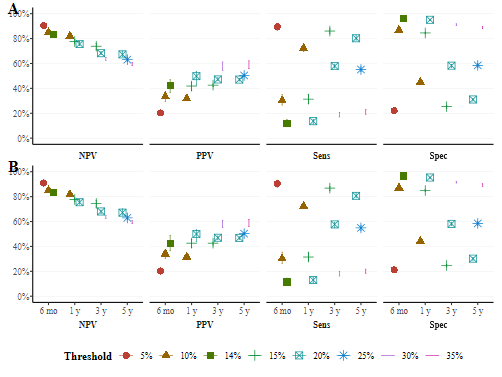

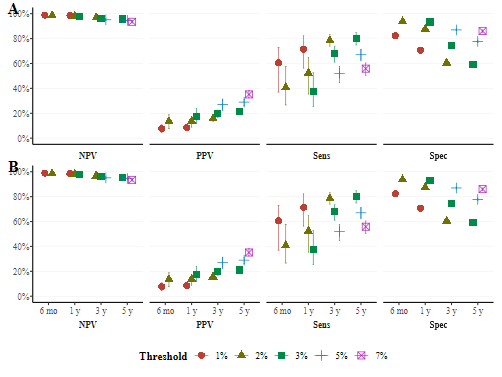

In [ ]:
#| label: threshold-metrics-plot
#| message: false
#| fig-width: 10
#| fig-height: 5

source(file.path(project_root, "cons/_hist_scripts/plot_threshold_metrics_from_summary_long.R"))

# panel_models MUST match the labels passed to run_threshold_metrics_*.
# Points = mean across CV replicates; bars = empirical 2.5th-97.5th percentiles
# (split-to-split spread, NOT confidence intervals).
figs_thr_metrics <- plot_threshold_metrics_separate_outcomes(
  summary_long = threshold_out_best2$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("Full PH updated2", "SHAP primary"),
  panel_titles = c("Full PH", "SHAP primary"),
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  save_files   = FALSE
)

# Render both figures
print(figs_thr_metrics$outcomes$Readmission$plot)
print(figs_thr_metrics$outcomes$Death$plot)


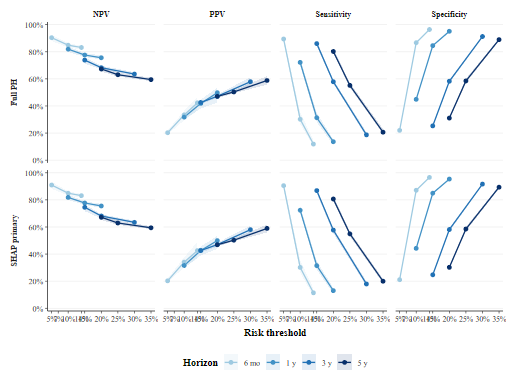

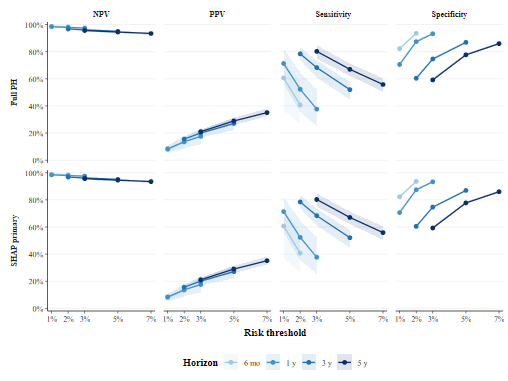

In [ ]:
#| label: threshold-metrics-epidemiology-corrected
#| results: hold
source(file.path(project_root, "cons/_alt_scripts/plot_threshold_metrics_clean.R"))

figs_thr_metrics <- plot_threshold_metrics_clean(
  summary_long = threshold_out_best2$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("Full PH updated2", "SHAP primary"),
  panel_titles = c("Full PH", "SHAP primary"),
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  uncertainty  = "ribbon",   # "errorbar" o "none" si lo quieres aún más limpio
  save_files   = FALSE
)

print(figs_thr_metrics$outcomes$Readmission$plot)
print(figs_thr_metrics$outcomes$Death$plot)


In [ ]:
#| label: threshold-metrics-epidemiology2
#| results: hold

# ── Threshold metrics: best_perf vs best_perf2 ────────────────────────────────
threshold_out_bestperf12 <- run_threshold_metrics_from_results_boot(
  results_boot_reference = results_shap_xgb_py_upd_best_perf,   # best_perf
  results_boot_updated   = results_shap_xgb_py_upd_best_perf2,  # best_perf2
  threshold_spec  = threshold_spec,        # mismo spec de la celda anterior
  reference_label = "SHAP primary",        # best_perf
  updated_label   = "SHAP implemented",    # best_perf2
  estimator       = "ipcw",                # competing-risk readmission; admin-IPCW death
  output_dir = file.path(project_root, "cons", "_out", "threshold_metrics_bestperf12"),
  prefix     = "threshold_metrics_bestperf12"
)
cat(sprintf("Readmission competing-risk reps=%d | fallback=%d\n",
            threshold_out_bestperf12$config$n_readmit_competing_risk,
            threshold_out_bestperf12$config$n_readmit_ipcw_fallback))


Threshold metrics: IPCW. Readmission competing-risk on 50 replicate(s). Death: admin-censoring IPCW.
Readmission competing-risk reps=50 | fallback=0


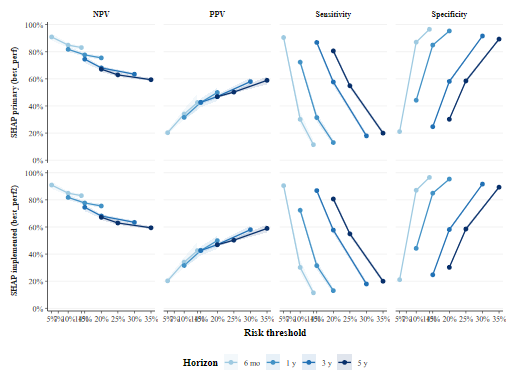

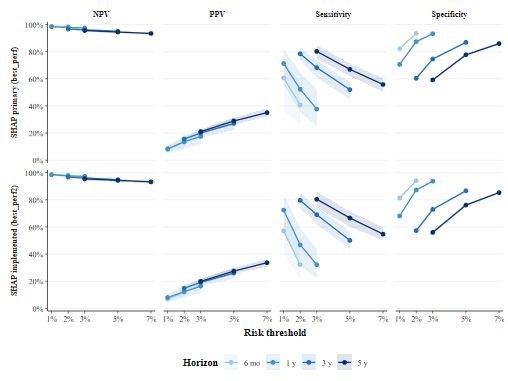

In [ ]:
#| label: threshold-metrics-epidemiology3
#| results: hold

figs_bestperf12 <- plot_threshold_metrics_clean(
  summary_long = threshold_out_bestperf12$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("SHAP primary", "SHAP implemented"),
  panel_titles = c("SHAP primary (best_perf)", "SHAP implemented (best_perf2)"),
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  uncertainty  = "ribbon",
  save_files   = FALSE
)
print(figs_bestperf12$outcomes$Readmission$plot)
print(figs_bestperf12$outcomes$Death$plot)


In [ ]:
#| label: threshold-metrics-epidemiology4-save
#| results: hold
source(file.path(project_root, "cons/_alt_scripts/save_threshold_metric_figures.R"))

out_fig <- file.path(project_root, "cons", "_figs")

# Figura principal (Full PH vs SHAP primary)
save_threshold_metric_figures(
  figs_thr_metrics, output_dir = out_fig,
  prefix  = "threshold_clean_primary",
  formats = c("png", "pdf", "tiff"))

# Figura best_perf vs best_perf2
save_threshold_metric_figures(
  figs_bestperf12, output_dir = out_fig,
  prefix  = "threshold_clean_bestperf12",
  formats = c("png", "pdf", "tiff"))


Saved 6 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 24 warnings (use warnings() to see them)


Saved 6 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 24 warnings (use warnings() to see them)


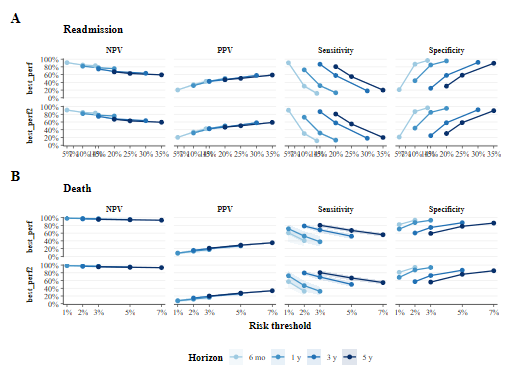

In [ ]:
#| label: threshold-metrics-epidemiology5-combined
#| results: hold
source(file.path(project_root, "cons/_alt_scripts/plot_threshold_metrics_clean.R"))
source(file.path(project_root, "cons/_alt_scripts/plot_threshold_metrics_clean_combined.R"))

fig_comb_bp12 <- plot_threshold_metrics_clean_combined(
  summary_long = threshold_out_bestperf12$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("SHAP primary", "SHAP implemented"),  # debe calzar con summary_long
  panel_titles = c("best_perf", "best_perf2"),           # rótulo de fila (libre)
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  uncertainty  = "ribbon"
)
print(fig_comb_bp12$plot)


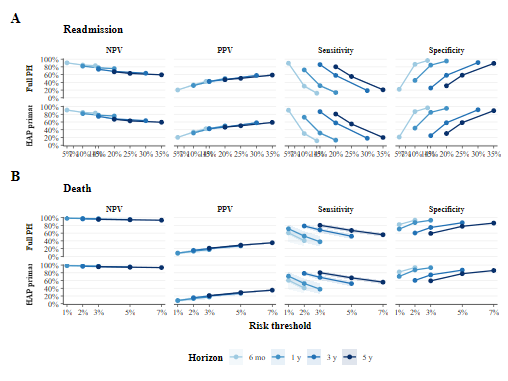

In [ ]:
#| label: threshold-metrics-epidemiology5-plot2
#| results: hold
fig_comb_primary <- plot_threshold_metrics_clean_combined(
  summary_long = threshold_out_best2$summary_long,
  panel_models = c("Full PH updated2", "SHAP primary"),
  panel_titles = c("Full PH", "SHAP primary"),
  uncertainty  = "ribbon"
)
print(fig_comb_primary$plot)


In [ ]:
#| label: threshold-metrics-epidemiology6-save-combined
#| results: hold
out_fig <- file.path(project_root, "cons", "_figs")

save_threshold_metric_figures(
  fig_comb_bp12, output_dir = out_fig,
  prefix    = "threshold_clean_bestperf12_combined",
  height_cm = 20, width_cm = 19,
  formats   = c("png", "pdf", "tiff"))

save_threshold_metric_figures(
  fig_comb_primary, output_dir = out_fig,
  prefix    = "threshold_clean_fullph_shap_combined",
  height_cm = 20, width_cm = 19,
  formats   = c("png", "pdf", "tiff"))

Saved 3 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 33 warnings (use warnings() to see them)


Saved 3 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 29 warnings (use warnings() to see them)


In [ ]:
#| label: threshold-metrics-table-html
#| message: false
#| results: asis

library(htmltools)

thr_tbl <- threshold_out_best2$summary_wide  # one row per Model x Risk x Time x Threshold

utils::write.csv(
  thr_tbl,
  file.path(project_root, "cons", "_out", "table_threshold_metrics_best2.csv"),
  row.names = FALSE
)

htmltools::browsable(htmltools::tags$div(
  style = "max-height:550px; overflow:auto; border:1px solid #ddd; font-family:Arial, sans-serif; font-size:12px;",
  htmltools::tags$table(
    style = "border-collapse:collapse; width:max-content; min-width:100%;",
    htmltools::tags$thead(htmltools::tags$tr(lapply(names(thr_tbl), function(nm)
      htmltools::tags$th(style = "position:sticky; top:0; background:#f3f3f3; border-bottom:1px solid #ccc; padding:4px 8px; text-align:left; white-space:nowrap;", nm)))),
    htmltools::tags$tbody(lapply(seq_len(nrow(thr_tbl)), function(i)
      htmltools::tags$tr(lapply(thr_tbl[i, ], function(x)
        htmltools::tags$td(style = "border-bottom:1px solid #eee; padding:3px 8px; white-space:nowrap;", as.character(x))))))
  )
))

Model,Risk,Time,Threshold,n_replicates,mean_valid_n,mean_cases_n,mean_controls_n,mean_pred_positive_n,NPV,PPV,Sens,Spec,F1
Full PH updated2,Death,6,0.01,25,12911.6,92.6,12819,2574.96,0.988 (0.981 to 0.993),0.077 (0.047 to 0.107),0.607 (0.370 to 0.729),0.823 (0.813 to 0.834),0.136 (0.085 to 0.184)
Full PH updated2,Death,6,0.02,25,12911.6,92.6,12819,952.48,0.985 (0.978 to 0.990),0.134 (0.079 to 0.187),0.407 (0.266 to 0.577),0.936 (0.931 to 0.945),0.200 (0.125 to 0.279)
Full PH updated2,Death,12,0.01,25,12464.6,141.2,12323.4,4251.72,0.985 (0.977 to 0.990),0.084 (0.059 to 0.108),0.714 (0.563 to 0.823),0.706 (0.695 to 0.715),0.151 (0.107 to 0.190)
Full PH updated2,Death,12,0.02,25,12464.6,141.2,12323.4,1868.12,0.980 (0.971 to 0.985),0.136 (0.089 to 0.171),0.523 (0.354 to 0.648),0.875 (0.867 to 0.884),0.216 (0.145 to 0.268)
Full PH updated2,Death,12,0.03,25,12464.6,141.2,12323.4,1012.2,0.975 (0.967 to 0.982),0.175 (0.117 to 0.238),0.377 (0.254 to 0.527),0.933 (0.927 to 0.942),0.238 (0.164 to 0.324)
Full PH updated2,Death,36,0.02,25,9745.8,340,9405.8,5813.48,0.968 (0.961 to 0.976),0.156 (0.134 to 0.173),0.785 (0.740 to 0.833),0.604 (0.594 to 0.616),0.260 (0.227 to 0.284)
Full PH updated2,Death,36,0.03,25,9745.8,340,9405.8,3836.44,0.962 (0.953 to 0.969),0.201 (0.167 to 0.225),0.683 (0.611 to 0.735),0.747 (0.739 to 0.756),0.310 (0.264 to 0.343)
Full PH updated2,Death,36,0.05,25,9745.8,340,9405.8,2078.68,0.951 (0.943 to 0.959),0.271 (0.223 to 0.314),0.521 (0.447 to 0.578),0.870 (0.862 to 0.878),0.356 (0.303 to 0.400)
Full PH updated2,Death,60,0.03,25,6811.2,475.8,6335.4,6274.16,0.957 (0.946 to 0.965),0.211 (0.192 to 0.225),0.803 (0.749 to 0.847),0.592 (0.583 to 0.606),0.333 (0.306 to 0.352)
Full PH updated2,Death,60,0.05,25,6811.2,475.8,6335.4,3720.68,0.946 (0.937 to 0.954),0.290 (0.260 to 0.313),0.670 (0.623 to 0.713),0.778 (0.770 to 0.787),0.404 (0.368 to 0.428)


---
## 8. Save environment for later use

In [ ]:
#| label: save-results
#| message: false

gc()

out_dir  <- file.path(project_root, "data", "20241015_out")
out_stem <- sprintf("pred225_metrics_%s", format(Sys.Date(), "%Y_%m_%d"))

# ── Strip individual-level data before saving ─────────────────────────────────
# Handles a single result object (has $raw_predictions directly) OR
# a named list of result objects (each element may have $raw_predictions).
.strip_raw <- function(obj) {
  if (!is.list(obj)) return(obj)
  if ("raw_predictions" %in% names(obj)) {        # single result object
    obj$raw_predictions <- NULL
    return(obj)
  }
  lapply(obj, function(m) {                        # named list of results
    if (is.list(m) && "raw_predictions" %in% names(m)) m$raw_predictions <- NULL
    m
  })
}

# ── Formulas — pred21/22 always saved these; small, no patient data ───────────
formula_names_all <- c(
  "formula_readmit",               "formula_readmit_updated",    "formula_readmit_updated2",
  "formula_death",                 "formula_death_updated",      "formula_death_updated2",
  "formula_shap_readmit_clean",    "formula_shap_readmit_clean_updated",
  "formula_shap_readmit_interact",
  "formula_shap_death",            "formula_shap_death_interact", 
  "formula_shap_ds_readmit_clean_updated", "formula_shap_ds_readmit_interact",
  "formula_shap_ds_death_updated", "formula_shap_ds_death_interact"
)
formulas_agg <- Filter(Negate(is.null),
  setNames(
    lapply(formula_names_all, function(fn) if (exists(fn)) get(fn) else NULL),
    formula_names_all
  )
)

# ── Primary eval results loaded from pred22 — strip raw_predictions ───────────
# These were saved by save.image() in pred22 and contain individual patient data.
# results_upd2_py               = Full PH updated2 (readmit + death)
# results_shap_xgb_py_upd_best_perf   = SHAP clean (primary model)
# results_shap_xgb_py_upd_best_perf3  = SHAP readmit + interact
# results_shap_xgb_py_upd_best_perf2 = implementation combo:
# formula_shap_readmit_clean_updated + formula_shap_death
pred22_results_agg <- Filter(Negate(is.null), list(
  results_upd2_py = if (exists("results_upd2_py"))
    .strip_raw(results_upd2_py) else NULL,
  results_shap_xgb_py_upd_best_perf = if (exists("results_shap_xgb_py_upd_best_perf"))
    .strip_raw(results_shap_xgb_py_upd_best_perf) else NULL,
  results_shap_xgb_py_upd_best_perf2 = if (exists("results_shap_xgb_py_upd_best_perf2"))
    .strip_raw(results_shap_xgb_py_upd_best_perf2) else NULL,
  results_shap_xgb_py_upd_best_perf3 = if (exists("results_shap_xgb_py_upd_best_perf3"))
    .strip_raw(results_shap_xgb_py_upd_best_perf3) else NULL
))

# ── DCA bundle ────────────────────────────────────────────────────────────────
dca_agg <- Filter(Negate(is.null), list(
  models_full    = if (exists("dca_models_full"))          dca_models_full          else NULL,
  nb_full_ph     = if (exists("dca_nb_full_ph"))           dca_nb_full_ph           else NULL,
  nb_shap_clean  = if (exists("dca_nb_shap_clean"))        dca_nb_shap_clean        else NULL,
  nb_implemented = if (exists("dca_nb_shap_implemented"))  dca_nb_shap_implemented  else NULL,
  dca_readmit    = if (exists("dca_readmit"))              dca_readmit              else NULL,
  dca_death      = if (exists("dca_death"))                dca_death                else NULL
))
if (length(dca_agg) == 0L) dca_agg <- NULL


# NRI/IDI and threshold metrics - compact, no raw replicate payload
.nri_idi_compact <- function(x) {
  if (!is.list(x)) return(x)
  Filter(Negate(is.null), list(
    summary = x$summary,
    config  = x$config
  ))
}
.threshold_compact <- function(x) {
  if (!is.list(x)) return(x)
  Filter(Negate(is.null), list(
    summary_long = x$summary_long,
    summary_wide = x$summary_wide,
    thresholds   = x$thresholds,
    config       = x$config
  ))
}
.get_if_exists <- function(nm) {
  if (exists(nm, inherits = TRUE)) get(nm, inherits = TRUE) else NULL
}
nri_idi_object_names <- c(
  best2    = "nri_idi_best2",
  best2vs1 = "nri_idi_best2vs1"
)
nri_idi_agg <- Filter(Negate(is.null),
  lapply(nri_idi_object_names, function(nm) {
    x <- .get_if_exists(nm)
    if (is.null(x)) NULL else .nri_idi_compact(x)
  })
)
nri_idi_table_names <- c(
  best2    = "nri_idi_model_table",
  best2vs1 = "nri_idi_model_table2"
)
nri_idi_tables_agg <- Filter(Negate(is.null),
  lapply(nri_idi_table_names, .get_if_exists)
)
# ── Bundle all aggregate results ──────────────────────────────────────────────
results_agg <- Filter(Negate(is.null), list(
  # Model definitions (needed to reproduce any fit)
  formulas           = if (length(formulas_agg) > 0L) formulas_agg else NULL,
  # Primary pred22 eval results, stripped (same coverage as pred22 save.image but safe)
  pred22_results     = if (length(pred22_results_agg) > 0L) pred22_results_agg else NULL,
  # Calibration: readmission (pooled_summary, rep_results, flat, calibration_curves)
  cal_readmit        = if (exists("cal_results"))       cal_results       else NULL,
  # Calibration: death
  cal_death_flat     = if (exists("death_cal_results")) death_cal_results else NULL,
  cal_death_full     = if (exists("death_cal_full"))    death_cal_full    else NULL,
  # Dual metrics from this notebook (strip raw_predictions)
  dual_pending       = if (exists("dual_pending_results")) .strip_raw(dual_pending_results) else NULL,
  ds_dual            = if (exists("ds_dual_results"))      .strip_raw(ds_dual_results)      else NULL,
  # Add to results_agg bundle (after cal_death_full):
  cal_readmit_ds     = if (exists("cal_results_ds"))        cal_results_ds        else NULL,
  cal_death_ds_flat  = if (exists("death_cal_results_ds"))  death_cal_results_ds  else NULL,
  cal_death_ds_full  = if (exists("death_cal_full_ds"))     death_cal_full_ds     else NULL,
  # DCA (aggregate net-benefit tables only)
  dca                = dca_agg,
  # Summary tables
  ici_readmit_table  = if (exists("ici_readmit_table"))   ici_readmit_table   else NULL,
  ici_death_table    = if (exists("ici_death_table"))     ici_death_table     else NULL,
  consolidated_table = if (exists("consolidated_table"))  consolidated_table  else NULL,
  nri_idi        = if (length(nri_idi_agg) > 0L) nri_idi_agg else NULL,
  nri_idi_tables = if (length(nri_idi_tables_agg) > 0L) nri_idi_tables_agg else NULL,
  threshold_metrics  = if (exists("threshold_out_best2")) .threshold_compact(threshold_out_best2) else NULL,
  threshold_table    = if (exists("thr_tbl")) thr_tbl else NULL
))

# ── RDS: single named list, no namespace pollution on load ────────────────────
rds_path <- file.path(out_dir, paste0(out_stem, ".rds"))
saveRDS(results_agg, rds_path)
cat("Saved RDS:", rds_path, "\n")

# ── CSV exports for flat tables ───────────────────────────────────────────────
csv_dir <- file.path(project_root, "cons", "_out")
if (!dir.exists(csv_dir)) dir.create(csv_dir, recursive = TRUE)

csv_exports <- Filter(Negate(is.null), list(
  ici_readmit_multihorizonte = if (exists("ici_readmit_table"))   ici_readmit_table   else NULL,
  ici_death_multihorizonte   = if (exists("ici_death_table"))     ici_death_table     else NULL,
  tabla_consolidada_dual     = if (exists("consolidated_table"))  consolidated_table  else NULL,
  nri_idi_best2              = if (exists("nri_idi_model_table"))  nri_idi_model_table  else NULL,
  nri_idi_best2vs1           = if (exists("nri_idi_model_table2")) nri_idi_model_table2 else NULL,
  threshold_metrics_best2    = if (exists("thr_tbl")) thr_tbl else NULL
))
for (nm in names(csv_exports)) {
  p <- file.path(csv_dir, paste0(nm, ".csv"))
  utils::write.csv(csv_exports[[nm]], p, row.names = FALSE)
  cat("  CSV:", basename(p), "\n")
}

# ── Summary ───────────────────────────────────────────────────────────────────
cat("\nObjects in RDS:\n")
for (nm in names(results_agg)) cat(sprintf("  - %s\n", nm))
cat(sprintf("\n  formulas saved: %d | pred22 results stripped: %d\n",
            length(results_agg$formulas), length(results_agg$pred22_results)))
cat("NOT saved: py_corrected_datasets* (individual patient data)\n")
cat("NOT saved: raw_predictions in any evaluate_dual_cox result\n")
cat("Load with: results_agg <- readRDS('", basename(rds_path), "')\n", sep = "")

Saved RDS: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred225_metrics_2026_05_30.rds 
  CSV: ici_readmit_multihorizonte.csv 
  CSV: ici_death_multihorizonte.csv 
  CSV: tabla_consolidada_dual.csv 
  CSV: nri_idi_best2.csv 
  CSV: nri_idi_best2vs1.csv 
  CSV: threshold_metrics_best2.csv 

Objects in RDS:
  - formulas
  - pred22_results
  - cal_readmit
  - cal_death_flat
  - cal_death_full
  - dual_pending
  - ds_dual
  - cal_readmit_ds
  - cal_death_ds_flat
  - cal_death_ds_full
  - dca
  - ici_readmit_table
  - ici_death_table
  - consolidated_table
  - nri_idi
  - nri_idi_tables
  - threshold_metrics
  - threshold_table

  formulas saved: 15 | pred22 results stripped: 3
NOT saved: py_corrected_datasets* (individual patient data)
NOT saved: raw_predictions in any evaluate_dual_cox result
Load with: results_agg <- readRDS('pred225_metrics_2026_05_30.rds')


In [ ]:
gc()

             used    (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells   15193974   811.5   22830264  1219.3   22830264  1219.3
Vcells 4273941938 32607.6 6495841445 49559.4 5796748073 44225.7

Save the main database with which we made the 80/20 split

In [ ]:
#| label: save-corrected-datasets-original
saveRDS(
  object = corrected_datasets_nondum_filt,
  file   = file.path("data", "20241015_out", "corrected_datasets_nondum_filt.rds")
)

In [ ]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

R library: G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
Date: 2026-05-31 17:22:40.566661
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpAzKCfO/file35681f105f09 -V' had status 1


1,abind,1.4-8,RSPM
2,backports,1.5.0,RSPM
3,base64enc,0.1-3,RSPM
4,boot,1.3-30,CRAN (R 4.4.1)
5,broom,1.0.7,RSPM
6,cachem,1.1.0,RSPM
7,car,3.1-3,RSPM
8,carData,3.0-5,RSPM
9,caret,7.0-1,RSPM
10,checkmate,2.3.2,RSPM (R 4.4.0)
11,class,7.3-22,CRAN (R 4.4.1)
